---

## EDA, Sistema de Predicción Energética y Alerta Temprana en Barrios de Barcelona

> **Contexto:** Dataset con consumo eléctrico por código postal (bloques de 6h, 2019–2025), enriquecido con variables meteorológicas de estaciones Meteocat y temperatura superficial satelital (MODIS LST). El objetivo es **predecir el consumo eléctrico a nivel de barrio con horizonte 24–72h** y generar alertas tempranas de picos de demanda.

### Variables del dataset

| Variable | Tipo | Descripción |
|---|---|---|
| `cod_postal` | Categórica | Código postal de Barcelona (08001–08042) |
| `nombre_postal` | Categórica | Nombre del barrio asociado al código postal |
| `centroide_lon` | Numérica | Longitud del centroide del código postal |
| `centroide_lat` | Numérica | Latitud del centroide del código postal |
| `codi_estacio` | Categórica | Código de estación Meteocat asignada |
| `nombre_estacio` | Categórica | Nombre de la estación Meteocat asignada |
| `estacio_lon` | Numérica | Longitud de la estación Meteocat asignada |
| `estacio_lat` | Numérica | Latitud de la estación Meteocat asignada |
| `datetime` | Temporal | Inicio del bloque de 6 horas |
| `mwh_total` | Target | Consumo eléctrico total en MWh |
| `mwh_industria` | Numérica | Consumo sector industria |
| `mwh_residencial` | Numérica | Consumo sector residencial |
| `mwh_servicios` | Numérica | Consumo sector servicios |
| `mwh_no_especificado` | Numérica | Consumo no clasificado |
| `lst_celsius` | Numérica | Land Surface Temperature — MODIS (°C) |
| `temp_mean` | Numérica | Temperatura media Meteocat (°C) |
| `temp_max` | Numérica | Temperatura máxima Meteocat (°C) |
| `temp_min` | Numérica | Temperatura mínima Meteocat (°C) |
| `humedad_mean` | Numérica | Humedad relativa media (%) |
| `viento_mean` | Numérica | Velocidad media del viento (m/s) |
| `precipitacion_sum` | Numérica | Precipitación acumulada en el bloque (mm) |
| `irradiancia_mean` | Numérica | Irradiancia solar global media (W/m²) |
| `es_festivo` | Binaria | Es día festivo |
| `nombre_local` | Categórica | Nombre del festivo local |
| `hora` | Ordinal | Hora de inicio del bloque (0, 6, 12, 18) |
| `dia_semana` | Ordinal | Día de la semana (0=Lunes, 6=Domingo) |
| `mes` | Ordinal | Mes del año (1–12) |
| `anio` | Numérica | Año |
| `semana_anio` | Numérica | Semana del año (1–53) |
| `es_finde` | Binaria | Es fin de semana |

---
## <font color='#4E8F6E'>  **Librerías** </font>


In [1]:
import polars as pl
import polars.selectors as cs
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np
import scipy.stats as stats
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from pymongo import MongoClient
from statsmodels.tsa.seasonal import STL
from datetime import date



plt.rcParams['axes.grid'] = True
plt.rcParams['grid.color'] = '#D3D3D3'
plt.rcParams['grid.linewidth'] = 0.4
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

verde   = '#4E8F6E'
naranja  = '#E07B5A'
amarillo = '#D4B93A'
azul    = '#2B6CB0'

---
# <font color='#4E8F6E'>  **Carga y Exploración** </font>


In [2]:
client = MongoClient('mongodb://mongo:27017/')
db     = client['tfm_energy']

docs = list(db['dataset_eda'].find({}, {'_id': 0}))
df   = pl.DataFrame(docs, infer_schema_length=None)


In [3]:
df.head(6)

cod_postal,nombre_postal,centroide_lon,centroide_lat,codi_estacio,nombre_estacio,estacio_lon,estacio_lat,datetime,mwh_total,mwh_industria,mwh_residencial,mwh_servicios,mwh_no_especificado,lst_celsius,temp_mean,temp_max,temp_min,humedad_mean,viento_mean,precipitacion_sum,irradiancia_mean,es_festivo,nombre_local,hora,dia_semana,mes,anio,semana_anio,es_finde
str,str,f64,f64,str,str,f64,f64,datetime[μs],i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,i64,str,i64,i64,i64,i64,i64,i64
"""08001""","""Las Ramblas / El Raval""",2.171735,41.38032,"""X4""","""Barcelona - el Raval""",2.1656,41.3793,2025-01-01 00:00:00,70044,287,32270,37487,null,11.45,10.183333,10.9,9.4,77.833333,1.058333,0.0,-2.0,1,"""Año Nuevo""",0,3,1,2025,1,0
"""08001""","""Las Ramblas / El Raval""",2.171735,41.38032,"""X4""","""Barcelona - el Raval""",2.1656,41.3793,2025-01-01 06:00:00,84422,366,38319,45737,null,11.45,11.25,14.2,9.1,70.0,0.841667,0.0,176.083333,1,"""Año Nuevo""",6,3,1,2025,1,0
"""08001""","""Las Ramblas / El Raval""",2.171735,41.38032,"""X4""","""Barcelona - el Raval""",2.1656,41.3793,2025-01-01 12:00:00,106367,417,53880,52070,null,11.45,12.916667,13.5,11.9,70.083333,1.083333,0.0,94.916667,1,"""Año Nuevo""",12,3,1,2025,1,0
"""08001""","""Las Ramblas / El Raval""",2.171735,41.38032,"""X4""","""Barcelona - el Raval""",2.1656,41.3793,2025-01-01 18:00:00,103864,342,54490,49032,null,11.45,11.036364,11.5,10.6,74.818182,1.1,0.0,-3.0,1,"""Año Nuevo""",18,3,1,2025,1,0
"""08002""","""Barri Gòtic""",2.174238,41.382826,"""X4""","""Barcelona - el Raval""",2.1656,41.3793,2025-01-01 00:00:00,63203,788,20754,41661,null,11.44,10.183333,10.9,9.4,77.833333,1.058333,0.0,-2.0,1,"""Año Nuevo""",0,3,1,2025,1,0
"""08002""","""Barri Gòtic""",2.174238,41.382826,"""X4""","""Barcelona - el Raval""",2.1656,41.3793,2025-01-01 06:00:00,74533,1024,23581,49928,null,11.44,11.25,14.2,9.1,70.0,0.841667,0.0,176.083333,1,"""Año Nuevo""",6,3,1,2025,1,0


In [4]:
df.tail(6)

cod_postal,nombre_postal,centroide_lon,centroide_lat,codi_estacio,nombre_estacio,estacio_lon,estacio_lat,datetime,mwh_total,mwh_industria,mwh_residencial,mwh_servicios,mwh_no_especificado,lst_celsius,temp_mean,temp_max,temp_min,humedad_mean,viento_mean,precipitacion_sum,irradiancia_mean,es_festivo,nombre_local,hora,dia_semana,mes,anio,semana_anio,es_finde
str,str,f64,f64,str,str,f64,f64,datetime[μs],i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,i64,str,i64,i64,i64,i64,i64,i64
"""08041""","""Sant Andreu""",2.174434,41.418288,"""AN""","""Barcelona - Parc de la Ciutade…",2.1859,41.3907,2019-12-31 12:00:00,66201,1767,45480,18954,null,13.18,null,null,null,null,null,null,null,0,null,12,2,12,2019,1,0
"""08041""","""Sant Andreu""",2.174434,41.418288,"""AN""","""Barcelona - Parc de la Ciutade…",2.1859,41.3907,2019-12-31 18:00:00,61506,1394,46538,13574,null,13.18,null,null,null,null,null,null,null,0,null,18,2,12,2019,1,0
"""08042""","""Torre Baró / Nou Barris""",2.172027,41.444412,"""AN""","""Barcelona - Parc de la Ciutade…",2.1859,41.3907,2019-12-31 00:00:00,41996,759,22909,18328,null,12.21,null,null,null,null,null,null,null,0,null,0,2,12,2019,1,0
"""08042""","""Torre Baró / Nou Barris""",2.172027,41.444412,"""AN""","""Barcelona - Parc de la Ciutade…",2.1859,41.3907,2019-12-31 06:00:00,69314,1058,31561,36695,null,12.21,null,null,null,null,null,null,null,0,null,6,2,12,2019,1,0
"""08042""","""Torre Baró / Nou Barris""",2.172027,41.444412,"""AN""","""Barcelona - Parc de la Ciutade…",2.1859,41.3907,2019-12-31 12:00:00,84494,879,45909,37706,null,12.21,null,null,null,null,null,null,null,0,null,12,2,12,2019,1,0
"""08042""","""Torre Baró / Nou Barris""",2.172027,41.444412,"""AN""","""Barcelona - Parc de la Ciutade…",2.1859,41.3907,2019-12-31 18:00:00,82006,778,48307,32921,null,12.21,null,null,null,null,null,null,null,0,null,18,2,12,2019,1,0


In [5]:
df.filter(pl.col("codi_estacio") == "X2").select(pl.col(["temp_mean", "temp_max", "temp_min", "humedad_mean", "viento_mean", "precipitacion_sum"])).head(6)

temp_mean,temp_max,temp_min,humedad_mean,viento_mean,precipitacion_sum
f64,f64,f64,f64,f64,f64
null,null,null,null,null,null
null,null,null,null,null,null
null,null,null,null,null,null
null,null,null,null,null,null
null,null,null,null,null,null
null,null,null,null,null,null


In [6]:
print(f"Shape: {df.shape}")
print(f"Desde: {df['datetime'].min()}")
print(f"Hasta: {df['datetime'].max()}")
print(f"Códigos postales únicos: {df['cod_postal'].n_unique()}")
print(f"Años cubiertos: {sorted(df['anio'].unique().to_list())}")


Shape: (424148, 30)
Desde: 2019-01-01 00:00:00
Hasta: 2025-11-30 18:00:00
Códigos postales únicos: 42
Años cubiertos: [2019, 2020, 2021, 2022, 2023, 2024, 2025]


In [7]:
# Tipos de datos
print("SCHEMA")
for col, dtype in zip(df.columns, df.dtypes):
    print(f"  {col:<30} {dtype}")


SCHEMA
  cod_postal                     String
  nombre_postal                  String
  centroide_lon                  Float64
  centroide_lat                  Float64
  codi_estacio                   String
  nombre_estacio                 String
  estacio_lon                    Float64
  estacio_lat                    Float64
  datetime                       Datetime(time_unit='us', time_zone=None)
  mwh_total                      Int64
  mwh_industria                  Int64
  mwh_residencial                Int64
  mwh_servicios                  Int64
  mwh_no_especificado            Int64
  lst_celsius                    Float64
  temp_mean                      Float64
  temp_max                       Float64
  temp_min                       Float64
  humedad_mean                   Float64
  viento_mean                    Float64
  precipitacion_sum              Float64
  irradiancia_mean               Float64
  es_festivo                     Int64
  nombre_local                   

In [8]:
pl.Config.set_tbl_rows(50)

nulls = (
    pl.DataFrame({
        'columna': df.columns,
        'nulos':   [df[c].null_count() for c in df.columns]
    })
    .with_columns((pl.col('nulos') / len(df) * 100).round(2).alias('pct_nulos'))
    .sort('nulos', descending=True)
    .filter(pl.col('nulos') > 0)
)

print(nulls)

shape: (12, 3)
┌─────────────────────┬────────┬───────────┐
│ columna             ┆ nulos  ┆ pct_nulos │
│ ---                 ┆ ---    ┆ ---       │
│ str                 ┆ i64    ┆ f64       │
╞═════════════════════╪════════╪═══════════╡
│ nombre_local        ┆ 407184 ┆ 96.0      │
│ mwh_no_especificado ┆ 362004 ┆ 85.35     │
│ lst_celsius         ┆ 168824 ┆ 39.8      │
│ viento_mean         ┆ 153201 ┆ 36.12     │
│ irradiancia_mean    ┆ 153196 ┆ 36.12     │
│ temp_mean           ┆ 136527 ┆ 32.19     │
│ temp_max            ┆ 136527 ┆ 32.19     │
│ temp_min            ┆ 136527 ┆ 32.19     │
│ humedad_mean        ┆ 136516 ┆ 32.19     │
│ precipitacion_sum   ┆ 136428 ┆ 32.17     │
│ mwh_industria       ┆ 2444   ┆ 0.58      │
│ mwh_residencial     ┆ 40     ┆ 0.01      │
└─────────────────────┴────────┴───────────┘


# Distribución por código postal

In [9]:
codpos_null = (
df.group_by('anio').agg([
    pl.col('irradiancia_mean').is_null().sum().alias('nulos_irradiancia'),
    pl.col('viento_mean').is_null().sum().alias('nulos_viento'),
    pl.col('temp_mean').is_null().sum().alias('nulos_temp'),
    pl.col('humedad_mean').is_null().sum().alias('nulos_humedad'),
    pl.len().alias('total_registros')
]).sort('anio'))

print(codpos_null)

shape: (7, 6)
┌──────┬───────────────────┬──────────────┬────────────┬───────────────┬─────────────────┐
│ anio ┆ nulos_irradiancia ┆ nulos_viento ┆ nulos_temp ┆ nulos_humedad ┆ total_registros │
│ ---  ┆ ---               ┆ ---          ┆ ---        ┆ ---           ┆ ---             │
│ i64  ┆ u32               ┆ u32          ┆ u32        ┆ u32           ┆ u32             │
╞══════╪═══════════════════╪══════════════╪════════════╪═══════════════╪═════════════════╡
│ 2019 ┆ 21900             ┆ 21900        ┆ 18980      ┆ 18980         ┆ 61320           │
│ 2020 ┆ 22504             ┆ 22504        ┆ 19616      ┆ 19616         ┆ 61488           │
│ 2021 ┆ 22440             ┆ 22440        ┆ 19560      ┆ 19560         ┆ 61320           │
│ 2022 ┆ 22116             ┆ 22123        ┆ 19219      ┆ 19219         ┆ 61320           │
│ 2023 ┆ 21900             ┆ 21900        ┆ 18980      ┆ 18980         ┆ 61320           │
│ 2024 ┆ 22094             ┆ 22078        ┆ 19923      ┆ 19919         ┆ 614

> Los nulls de viento e irradiancia son constantes por todos los años, puede ser que sean dias específicos del años o simepleemente que solo algunas estacionas puedan lograr tomar estas medidas. aproximadamente 17,500 nullos al año

> En cambio partes de 2024 y 2025 son valores un poco diferentes, que curiosamente se acercan a las constantes de nulos de irradiancia y viento

Nulls viento

In [10]:
codpos_null = (df.filter(pl.col('viento_mean').is_null())
    .group_by(['cod_postal','nombre_postal','codi_estacio'])
    .agg(pl.len().alias('nulos_viento'))
    .sort('nulos_viento', descending=True)
    .select(['cod_postal','nombre_postal', 'nulos_viento','codi_estacio']))

print(codpos_null)

shape: (42, 4)
┌────────────┬─────────────────────────────────┬──────────────┬──────────────┐
│ cod_postal ┆ nombre_postal                   ┆ nulos_viento ┆ codi_estacio │
│ ---        ┆ ---                             ┆ ---          ┆ ---          │
│ str        ┆ str                             ┆ u32          ┆ str          │
╞════════════╪═════════════════════════════════╪══════════════╪══════════════╡
│ 08041      ┆ Sant Andreu                     ┆ 10100        ┆ AN           │
│ 08026      ┆ El Clot / Camp de l'Arpa        ┆ 10100        ┆ AN           │
│ 08010      ┆ Pl. Catalunya / Gran Via        ┆ 10100        ┆ AN           │
│ 08030      ┆ El Bon Pastor / Sant Andreu     ┆ 10100        ┆ AN           │
│ 08019      ┆ El Besòs i el Maresme           ┆ 10100        ┆ AN           │
│ 08009      ┆ Dreta de l'Eixample             ┆ 10100        ┆ AN           │
│ 08020      ┆ La Verneda                      ┆ 10100        ┆ AN           │
│ 08016      ┆ Nou Barris            

> Los nulos de irradiancia y viento son estructurales desde 2019: la estación X2
> de Meteocat no dispone de estos sensores para la mayoría de códigos postales.
> No es un fallo temporal sino una limitación permanente de cobertura.

> La excepción es el código postal 08038, que tiene asignada otra estación
> con cobertura completa de variables, confirmando que el problema es de
> estación y no de los días o periodos de medición.

> En 2024 y 2025 los nulos de temperatura y humedad escalan bruscamente hasta
> igualarse con los de irradiancia y viento. Esto confirma la degradación
> progresiva y posterior inactividad de la estación X2, que en 2025 deja de
> reportar prácticamente todas las variables.

> Estrategia de imputación pendiente para feature engineering: reasignar X2
> a X4 o aplicar un factor de corrección histórico. MODIS actuará como
> fallback espacial para LST en periodos sin cobertura de estación.

In [11]:
df.group_by(["codi_estacio", "anio"]).agg([
    pl.len().alias("total_registros"),
    pl.col("temp_mean").is_null().sum().alias("nulos_temp"),
    pl.col("viento_mean").is_null().sum().alias("nulos_viento"),
    pl.col("irradiancia_mean").is_null().sum().alias("nulos_irradiancia"),
]).sort(["codi_estacio", "anio"])

codi_estacio,anio,total_registros,nulos_temp,nulos_viento,nulos_irradiancia
str,i64,u32,u32,u32,u32
"""AN""",2019,18980,18980,18980,18980
"""AN""",2020,19032,19032,19032,19032
"""AN""",2021,18980,18980,18980,18980
"""AN""",2022,18980,18980,18980,18980
"""AN""",2023,18980,18980,18980,18980
"""AN""",2024,19032,19032,19032,19032
"""AN""",2025,17316,17316,17316,17316
"""D5""",2019,10220,0,0,0
"""D5""",2020,10248,140,140,140


#### Estaciones con mejor cobertura

In [12]:
df.group_by("codi_estacio").agg([
    pl.len().alias("total"),
    pl.col("temp_mean").is_null().sum().alias("nulos_temp"),
    (pl.col("temp_mean").is_null().sum() / pl.len() * 100).round(2).alias("pct_nulos_temp")
]).sort("pct_nulos_temp")

codi_estacio,total,nulos_temp,pct_nulos_temp
str,u32,u32,f64
"""X4""",161548,928,0.57
"""X8""",40400,252,0.62
"""D5""",70700,567,0.8
"""X2""",20200,3480,17.23
"""AN""",131300,131300,100.0


- X4 : 0.57% nulos 
- X8 : 0.62% nulos 
- D5 : 0.80% nulos  
- X2 : 17.23% nulos 
- AN : 100% nulos

> **Estación AN — Parc de la Ciutadella:** Al cruzar el mapeo geográfico con los datos reales de MongoDB, se descubrió que AN y X2 (Zoo de Barcelona) se solapan físicamente, a menos de 200 metros dentro del mismo parque. Más importante aún, AN tiene el 100% de nulos en todas sus variables meteorológicas en todos los años (2019–2025), lo que confirma que AN existe como punto de referencia geográfico en Meteocat pero no dispone de sensores activos. Por esta razón, tomo la decisión de reasignar todos los registros originalmente asignados a AN hacia X2, que sí tiene datos de temperatura.

> **Estación X2 — Zoo de Barcelona:** X2 presenta dos limitaciones estructurales. Primero, nunca ha tenido sensores de viento ni irradiancia ya que ambas variables tienen el 100% de nulos en todos los años, lo cual no es un fallo sino una característica de la estación. Segundo, a partir de 2024 comienza a degradarse y en 2025 deja de funcionar completamente, con 2.664 nulos de temperatura sobre 2.664 registros totales. Para los CPs asignados a X2, las variables de viento e irradiancia deberán ser imputadas en la fase de feature engineering, ya sea mediante la estación más cercana con cobertura completa o mediante un factor de corrección basado en la diferencia de temperatura superficial con MODIS.

---
# <font color='#4E8F6E'>  **Limpieza inicial** </font>


> A partir de los hallazgos anteriores comenzaré con una limpieza inicial

### <font color='#D4B93A'><b>Datos Faltantes</b></font>

#### Datos sin registros en mwh_total

In [13]:
mwh_problematicos = df.filter(pl.col('mwh_total') <= 0)
print(f"Registros con mwh_total mayor o igual a 0: {len(mwh_problematicos):,}")

n_dupes = len(df) - df.unique(subset=['datetime', 'cod_postal']).shape[0]
print(f"Duplicados datetime + cod_postal: {n_dupes:,}")


Registros con mwh_total mayor o igual a 0: 378


Duplicados datetime + cod_postal: 0


> Existen 378 filas donde no existen valores iguales o menores a 0 en el mwh_total lo cual se puede tratar de un problema de recolección de datos

In [14]:
print(mwh_problematicos.select([
    "cod_postal", "nombre_postal", "datetime",
    "mwh_total", "mwh_industria", "mwh_residencial",
    "mwh_servicios", "mwh_no_especificado"
]))

shape: (378, 8)
┌────────────┬────────────┬────────────┬───────────┬───────────┬───────────┬───────────┬───────────┐
│ cod_postal ┆ nombre_pos ┆ datetime   ┆ mwh_total ┆ mwh_indus ┆ mwh_resid ┆ mwh_servi ┆ mwh_no_es │
│ ---        ┆ tal        ┆ ---        ┆ ---       ┆ tria      ┆ encial    ┆ cios      ┆ pecificad │
│ str        ┆ ---        ┆ datetime[μ ┆ i64       ┆ ---       ┆ ---       ┆ ---       ┆ o         │
│            ┆ str        ┆ s]         ┆           ┆ i64       ┆ i64       ┆ i64       ┆ ---       │
│            ┆            ┆            ┆           ┆           ┆           ┆           ┆ i64       │
╞════════════╪════════════╪════════════╪═══════════╪═══════════╪═══════════╪═══════════╪═══════════╡
│ 08001      ┆ Las        ┆ 2025-06-26 ┆ 0         ┆ 0         ┆ 0         ┆ 0         ┆ null      │
│            ┆ Ramblas /  ┆ 00:00:00   ┆           ┆           ┆           ┆           ┆           │
│            ┆ El Raval   ┆            ┆           ┆           ┆           

In [15]:
print(mwh_problematicos.select("datetime").unique().sort("datetime"))

shape: (9, 1)
┌─────────────────────┐
│ datetime            │
│ ---                 │
│ datetime[μs]        │
╞═════════════════════╡
│ 2025-06-26 00:00:00 │
│ 2025-06-26 06:00:00 │
│ 2025-06-26 12:00:00 │
│ 2025-08-30 00:00:00 │
│ 2025-08-30 06:00:00 │
│ 2025-08-30 12:00:00 │
│ 2025-09-07 00:00:00 │
│ 2025-09-07 06:00:00 │
│ 2025-09-07 12:00:00 │
└─────────────────────┘


In [16]:
fechas_problema = ["2025-06-26", "2025-08-30", "2025-09-07"]

df.filter(
    (pl.col("datetime").dt.date().cast(pl.Utf8).is_in(fechas_problema)) &
    (pl.col("datetime").dt.hour() == 18)
).select(["cod_postal", "datetime", "mwh_total"]).head(10)

cod_postal,datetime,mwh_total
str,datetime[μs],i64
"""08001""",2025-06-26 18:00:00,9128
"""08002""",2025-06-26 18:00:00,5176
"""08003""",2025-06-26 18:00:00,9266
"""08004""",2025-06-26 18:00:00,8587
"""08005""",2025-06-26 18:00:00,8008
"""08006""",2025-06-26 18:00:00,12091
"""08007""",2025-06-26 18:00:00,2200
"""08008""",2025-06-26 18:00:00,1660
"""08009""",2025-06-26 18:00:00,1892


In [17]:
mwh_problematicos.group_by("datetime") \
    .agg(pl.n_unique("cod_postal").alias("n_codigos")) \
    .sort("datetime")

datetime,n_codigos
datetime[μs],u32
2025-06-26 00:00:00,42
2025-06-26 06:00:00,42
2025-06-26 12:00:00,42
2025-08-30 00:00:00,42
2025-08-30 06:00:00,42
2025-08-30 12:00:00,42
2025-09-07 00:00:00,42
2025-09-07 06:00:00,42
2025-09-07 12:00:00,42


> Este error en lso datos existe durante todos lo días para los 42 códigos postales

> Se detectaron 378 registros con mwh_total = 0, concentrados en exactamente 
> 3 fechas de 2025 (26-jun, 30-ago, 07-sep). En cada caso, los bloques 00:00, 
> 06:00 y 12:00 de los 42 códigos postales reportaron cero simultáneamente, 
> mientras el bloque 18:00 del mismo día registró valores normales. 
> Patrón consistente con un fallo parcial de reporte en la fuente, no con 
> un corte real de suministro.

### <font color='#D4B93A'><b>Verificar continuidad temporal</b></font>

In [18]:
# Fechas completas esperadas cada 6 horas para cada código postal
fechas_completas = pl.datetime_range( 
    start=df['datetime'].min(),
    end=df['datetime'].max(),
    interval='6h',
    eager=True
).alias('datetime')

codigos_postales = df.select('cod_postal').unique()

# el corss join es para crear la combinacion completa de fechas para cada código postal
fechas_esperadas = codigos_postales.join(
    fechas_completas.to_frame(), how='cross'
)

print(f"Registros esperados: {len(fechas_esperadas):,}")
print(f"Registros reales:    {len(df):,}")
print(f"Registros faltantes: {len(fechas_esperadas) - len(df):,}")

#El antijoin para ver que valores de datetime + cod_postal no están en el dataset original
faltantes = fechas_esperadas.join(
    df.select(['cod_postal', 'datetime']),
    on=['cod_postal', 'datetime'],
    how='anti'
)

print("\nFechas con mayor número de CP faltantes:")
print(
    faltantes
    .group_by(pl.col('datetime').dt.date().alias('fecha'))
    .agg(pl.len().alias('cp_faltantes'))
    .sort('cp_faltantes', descending=True)
    .head(20)
)

Registros esperados: 424,368
Registros reales:    424,148
Registros faltantes: 220



Fechas con mayor número de CP faltantes:
shape: (14, 2)
┌────────────┬──────────────┐
│ fecha      ┆ cp_faltantes │
│ ---        ┆ ---          │
│ date       ┆ u32          │
╞════════════╪══════════════╡
│ 2025-08-19 ┆ 168          │
│ 2025-08-18 ┆ 4            │
│ 2025-08-09 ┆ 4            │
│ 2025-08-15 ┆ 4            │
│ 2025-08-16 ┆ 4            │
│ 2025-08-14 ┆ 4            │
│ 2025-08-13 ┆ 4            │
│ 2025-08-20 ┆ 4            │
│ 2025-08-17 ┆ 4            │
│ 2025-08-10 ┆ 4            │
│ 2025-08-12 ┆ 4            │
│ 2025-08-11 ┆ 4            │
│ 2025-08-08 ┆ 4            │
│ 2025-08-07 ┆ 4            │
└────────────┴──────────────┘


In [19]:
faltantes_por_dia = faltantes.with_columns(
    pl.col("datetime").dt.date().alias("fecha")
).group_by(["cod_postal", "fecha"]).count()

faltantes_por_dia.filter(
    pl.col("count") != 4  # 4 registros por día (cada 6h)
)

/tmp/ipykernel_2217/2924495419.py:3: DeprecationWarning: `GroupBy.count` is deprecated. It has been renamed to `len`.
  ).group_by(["cod_postal", "fecha"]).count()


cod_postal,fecha,count
str,date,u32


> A todos estos días les faltan 4 los 4 horarios

08011 (7–20 ago 2025): 52 bloques faltantes (13 días × 4). Problema de reporte específico del CP.
2025-08-19: día completo sin datos para los 42 CPs (168 bloques). Fallo de reporte en la fuente.

### <font color='#D4B93A'><b>Conversión de tipo de datos</b></font>

In [20]:
df = df.with_columns([
    pl.col('datetime').cast(pl.Datetime),
    pl.col('cod_postal').cast(pl.Utf8),
    pl.col('es_festivo').cast(pl.Int8),
    pl.col('es_finde').cast(pl.Int8),
    pl.col('hora').cast(pl.Int8),
    pl.col('dia_semana').cast(pl.Int8),
    pl.col('mes').cast(pl.Int8),
    pl.col('anio').cast(pl.Int16),
])
df.head(3)


cod_postal,nombre_postal,centroide_lon,centroide_lat,codi_estacio,nombre_estacio,estacio_lon,estacio_lat,datetime,mwh_total,mwh_industria,mwh_residencial,mwh_servicios,mwh_no_especificado,lst_celsius,temp_mean,temp_max,temp_min,humedad_mean,viento_mean,precipitacion_sum,irradiancia_mean,es_festivo,nombre_local,hora,dia_semana,mes,anio,semana_anio,es_finde
str,str,f64,f64,str,str,f64,f64,datetime[μs],i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,i8,str,i8,i8,i8,i16,i64,i8
"""08001""","""Las Ramblas / El Raval""",2.171735,41.38032,"""X4""","""Barcelona - el Raval""",2.1656,41.3793,2025-01-01 00:00:00,70044,287,32270,37487,null,11.45,10.183333,10.9,9.4,77.833333,1.058333,0.0,-2.0,1,"""Año Nuevo""",0,3,1,2025,1,0
"""08001""","""Las Ramblas / El Raval""",2.171735,41.38032,"""X4""","""Barcelona - el Raval""",2.1656,41.3793,2025-01-01 06:00:00,84422,366,38319,45737,null,11.45,11.25,14.2,9.1,70.0,0.841667,0.0,176.083333,1,"""Año Nuevo""",6,3,1,2025,1,0
"""08001""","""Las Ramblas / El Raval""",2.171735,41.38032,"""X4""","""Barcelona - el Raval""",2.1656,41.3793,2025-01-01 12:00:00,106367,417,53880,52070,null,11.45,12.916667,13.5,11.9,70.083333,1.083333,0.0,94.916667,1,"""Año Nuevo""",12,3,1,2025,1,0


> Se identificaron 378 registros con mwh_total = 0, correspondientes a los bloques de 00:00, 06:00 y 12:00 de tres fechas puntuales en 2025, estos son: 26 de junio, 30 de agosto y 7 de septiembre. 

> En los tres casos el patrón es idéntico: afectan a los 42 códigos postales simultáneamente y el bloque de 18:00 del mismo día reporta valores normales (por ejemplo, 08001 registró 9.128 MWh a las 18:00 del 26 de junio). 

> Esto descarta un apagón real y confirma un fallo parcial de reporte en la fuente Open Data BCN, limitado a los primeros tres bloques del día. Estos registros serán tratados como nulos en la fase de feature engineering.

### <font color='#D4B93A'><b>Trato de Nulls</b></font>

1. **Reasignación AN → X2** — variables meteorológicas rellenadas con datos reales de X2 desde MongoDB  
2. **Grilla temporal completa** — bloques faltantes (08011 ago 2025 + 19-ago global) rellenados con mediana histórica  
3. **Sectores de consumo** — `mwh_industria`, `mwh_residencial` y `mwh_servicios` imputados a 0 (sector no activo ese bloque); se recalcula `mwh_total`  
4. **Días con mwh_total = 0** — 3 fechas de fallo de reporte imputadas con mediana histórica 2019-2024  
5. **Nulls meteorológicos restantes** — `viento`, `irradiancia`, `temp`, `humedad`: estructurales, se mantienen para feature engineering

In [21]:
# ── 1. Reasignación AN → X2 ──────────────────────────────────────────────────
# AN y X2 se solapan físicamente (Zoo de Barcelona). AN tiene 100% nulos.
# Se renombra AN → X2 y se rellenan variables meteo con datos reales de X2.

df = df.with_columns([
    pl.when(pl.col("codi_estacio") == "AN").then(pl.lit("X2")).otherwise(pl.col("codi_estacio")).alias("codi_estacio"),
    pl.when(pl.col("codi_estacio") == "AN").then(pl.lit("Barcelona - Zoo")).otherwise(pl.col("nombre_estacio")).alias("nombre_estacio"),
    pl.when(pl.col("codi_estacio") == "AN").then(pl.lit(2.1898)).otherwise(pl.col("estacio_lon")).alias("estacio_lon"),
    pl.when(pl.col("codi_estacio") == "AN").then(pl.lit(41.3842)).otherwise(pl.col("estacio_lat")).alias("estacio_lat"),
])

docs_meteocat = list(db["clean_meteocat"].find({"codi_estacio": "X2"}, {"_id": 0}))
meteocat_x2 = (
    pl.DataFrame(docs_meteocat)
    .rename({"data_lectura": "datetime", "temp": "temp_mean", "humedad": "humedad_mean",
             "viento": "viento_mean", "precipitacion": "precipitacion_sum", "irradiancia": "irradiancia_mean"})
    .select(["datetime", "temp_mean", "humedad_mean", "viento_mean", "precipitacion_sum", "irradiancia_mean"])
)

df = df.join(meteocat_x2, on="datetime", how="left", suffix="_x2")

cols_meteo = ["temp_mean", "humedad_mean", "viento_mean", "precipitacion_sum", "irradiancia_mean"]
df = df.with_columns([
    pl.when(pl.col(c).is_null()).then(pl.col(f"{c}_x2")).otherwise(pl.col(c)).alias(c)
    for c in cols_meteo
]).drop([f"{c}_x2" for c in cols_meteo])

print("Reasignación AN → X2 completada")
print(df.group_by("codi_estacio").agg(pl.col("temp_mean").null_count().alias("nulos_temp"), pl.len().alias("total")).sort("codi_estacio"))

Reasignación AN → X2 completada
shape: (4, 3)
┌──────────────┬────────────┬────────┐
│ codi_estacio ┆ nulos_temp ┆ total  │
│ ---          ┆ ---        ┆ ---    │
│ str          ┆ u32        ┆ u32    │
╞══════════════╪════════════╪════════╡
│ D5           ┆ 560        ┆ 70700  │
│ X2           ┆ 26165      ┆ 151500 │
│ X4           ┆ 864        ┆ 161548 │
│ X8           ┆ 216        ┆ 40400  │
└──────────────┴────────────┴────────┘


### Estrategia de nulos meteorológicos, decisión EDA

**Variables: viento_mean, irradiancia_mean, precipitacion_sum**  
X2 no mide estas variables en ningún período.
- Mantener nulos. Si el EDA muestra diferencias significativas entre barrios, explorar fuentes alternativas (otras estaciones, ERA5).

**Variables: temp_mean, humedad_mean, período 2024 parcial y 2025**  
X2 inactiva. Datos reales disponibles para 2019–2023.
- Mantener nulos por ahora. Si el EDA confirma diferencias de comportamiento entre barrios (consumo vs temperatura), aplicar factor de corrección basado en la relación histórica X2/X4 de años anteriores.

**Criterio de decisión (post-EDA):**
- Si variación entre barrios es baja: nulos sin imputar, el modelo los gestiona
- Si variación entre barrios es alta: factor de corrección histórico X2/X4

In [22]:
# ── 2. Grilla temporal completa ───────────────────────────────────────────────
# 08011 tiene 52 bloques faltantes en ago 2025 y el 19-ago-2025 falta para todos los CPs.
# Se imputan con mediana histórica por CP + hora + dia_semana + mes (2019-2024).

fechas_esperadas = df.select('cod_postal').unique().join(
    pl.datetime_range(df['datetime'].min(), df['datetime'].max(), interval='6h', eager=True)
      .alias('datetime').to_frame(), how='cross'
)
faltantes = fechas_esperadas.join(df.select(['cod_postal', 'datetime']), on=['cod_postal', 'datetime'], how='anti')
print(f"Faltantes detectados: {len(faltantes):,}")
print(faltantes.filter(pl.col('datetime').dt.date() != date(2025, 8, 19))
               .group_by('cod_postal').agg(pl.len().alias('n')).sort('n', descending=True))

docs_festivos = list(db["clean_festivos"].find({}, {"_id": 0}))
fechas_festivas = set(
    pl.DataFrame(docs_festivos)
    .with_columns(pl.col("fecha").str.to_date("%Y-%m-%d"))["fecha"].to_list()
)

referencia = (
    df.filter(pl.col("anio") < 2025)
    .group_by(["cod_postal", "hora", "dia_semana", "mes"])
    .agg(pl.col("mwh_total").median().alias("mwh_total"))
)

df_faltantes = (
    faltantes
    .with_columns([
        pl.col("datetime").dt.hour().cast(pl.Int8).alias("hora"),
        pl.col("datetime").dt.weekday().cast(pl.Int8).alias("dia_semana"),
        pl.col("datetime").dt.month().cast(pl.Int8).alias("mes"),
    ])
    .join(referencia, on=["cod_postal", "hora", "dia_semana", "mes"], how="left")
    .with_columns(
        pl.col("datetime").dt.date()
          .map_elements(lambda d: 1 if d in fechas_festivas else 0, return_dtype=pl.Int64)
          .alias("es_festivo")
    )
)

df = pl.concat([df, df_faltantes], how="diagonal_relaxed").sort(["cod_postal", "hora", "datetime"])
print(f"Shape: {df.shape} | Nulls mwh_total: {df['mwh_total'].null_count()}")

Faltantes detectados: 220
shape: (1, 2)
┌────────────┬─────┐
│ cod_postal ┆ n   │
│ ---        ┆ --- │
│ str        ┆ u32 │
╞════════════╪═════╡
│ 08011      ┆ 52  │
└────────────┴─────┘
Shape: (424368, 30) | Nulls mwh_total: 0


> **08011 (7–20 ago 2025):** 52 bloques faltantes (13 días × 4). Problema de reporte específico del CP.

> **2025-08-19:** día completo sin datos para los 42 CPs (168 bloques). Fallo de reporte en la fuente.

> Ambos se imputan con mediana histórica por CP + hora + día semana + mes, usando 2019-2024.

In [23]:
# ── 3. Fill null sectores + recálculo mwh_total ───────────────────────────────
# Sectores sin dato = 0 (sector no activo ese bloque horario)

df = df.with_columns([
    pl.col("mwh_industria").fill_null(0),
    pl.col("mwh_residencial").fill_null(0),
    pl.col("mwh_servicios").fill_null(0),
])

df = df.with_columns(
    (pl.col("mwh_industria") + pl.col("mwh_residencial") +
     pl.col("mwh_servicios") + pl.col("mwh_no_especificado").fill_null(0)
    ).alias("mwh_total")
)

# Verificar nulos restantes
nulos = (
    df.null_count()
    .unpivot(variable_name="columna", value_name="nulos")
    .filter(pl.col("nulos") > 0)
    .with_columns((pl.col("nulos") / len(df) * 100).round(2).alias("pct"))
    .sort("nulos", descending=True)
)
print(f"Shape: {df.shape}")
print(nulos)

Shape: (424368, 30)
shape: (20, 3)
┌─────────────────────┬────────┬───────┐
│ columna             ┆ nulos  ┆ pct   │
│ ---                 ┆ ---    ┆ ---   │
│ str                 ┆ u32    ┆ f64   │
╞═════════════════════╪════════╪═══════╡
│ nombre_local        ┆ 407404 ┆ 96.0  │
│ mwh_no_especificado ┆ 362224 ┆ 85.36 │
│ lst_celsius         ┆ 169044 ┆ 39.83 │
│ viento_mean         ┆ 153421 ┆ 36.15 │
│ irradiancia_mean    ┆ 153416 ┆ 36.15 │
│ temp_max            ┆ 136747 ┆ 32.22 │
│ temp_min            ┆ 136747 ┆ 32.22 │
│ precipitacion_sum   ┆ 136648 ┆ 32.2  │
│ temp_mean           ┆ 28025  ┆ 6.6   │
│ humedad_mean        ┆ 28018  ┆ 6.6   │
│ nombre_postal       ┆ 220    ┆ 0.05  │
│ centroide_lon       ┆ 220    ┆ 0.05  │
│ centroide_lat       ┆ 220    ┆ 0.05  │
│ codi_estacio        ┆ 220    ┆ 0.05  │
│ nombre_estacio      ┆ 220    ┆ 0.05  │
│ estacio_lon         ┆ 220    ┆ 0.05  │
│ estacio_lat         ┆ 220    ┆ 0.05  │
│ anio                ┆ 220    ┆ 0.05  │
│ semana_anio         

In [24]:
# ── 4. Imputar mwh_total = 0 (3 fechas de fallo de reporte en 2025) ───────────
# 26-jun, 30-ago y 07-sep 2025: mwh_total = 0 para los 42 CPs por error en OpenData.
# Se imputa con mediana histórica por CP + hora + dia_semana + mes (2019-2024).

referencia_ceros = (
    df.filter((pl.col("anio") < 2025) & (pl.col("mwh_total") > 0))
    .group_by(["cod_postal", "hora", "dia_semana", "mes"])
    .agg(pl.col("mwh_total").median().alias("mwh_ref"))
)

df = (
    df.join(referencia_ceros, on=["cod_postal", "hora", "dia_semana", "mes"], how="left")
    .with_columns(
        pl.when(pl.col("mwh_total") == 0)
          .then(pl.col("mwh_ref"))
          .otherwise(pl.col("mwh_total"))
          .alias("mwh_total")
    )
    .drop("mwh_ref")
)

print(f"Ceros restantes: {df.filter(pl.col('mwh_total') == 0).shape[0]}")
print(f"Nulls mwh_total: {df['mwh_total'].null_count()}")

Ceros restantes: 0
Nulls mwh_total: 0


> **Resumen del tratamiento de nulos:**
>
> - **Reasignación AN → X2** — los registros de la estación AN (100% nulos, Zoo de Barcelona) se reasignaron a X2 y se rellenaron con datos reales de Meteocat para temp y humedad (2019–2023).
>
> - **Sectores de consumo** — `mwh_industria`, `mwh_residencial` y `mwh_servicios` nulos imputados a 0 (sector no activo ese bloque). `mwh_total` recalculado como suma de los 4 sectores.
>
> - **Continuidad temporal** — 220 bloques añadidos: 52 del CP 08011 (7–20 ago 2025, fallo de reporte específico) y 168 del 19-ago-2025 global (42 CPs × 4 bloques). Imputados con mediana histórica por CP + hora + día semana + mes (2019–2024).
>
> - **mwh_total = 0** — 378 registros en 3 fechas de 2025 (26-jun, 30-ago, 07-sep). Fallo parcial de reporte en OpenData — bloques 00:00, 06:00 y 12:00 en cero mientras el 18:00 era normal. Imputados con mediana histórica por CP + hora + día semana + mes (2019–2024).
>
> - **Nulos meteorológicos restantes** — viento e irradiancia (X2 sin sensores en todo el período), temp/humedad 2024–2025 (X2 inactiva). Estructurales y conocidos, se mantienen para feature engineering.

---
# <font color='#4E8F6E'>  **Análisis Descriptivo** </font>


## <font color='#4E8F6E'>  **Variable Objetivo: mwh_total** </font>


1. Variable objetivo — distribución
   → histograma, boxplot, describe() ← ya lo tienes

2. Variable objetivo — comportamiento temporal
   → serie en el tiempo, descomposición STL, ACF/PACF, ADF/KPSS

3. Variables explicativas numéricas
   → histogramas, QQ-plots, correlación con mwh_total

4. Variables explicativas categóricas/temporales
   → consumo por hora, día, mes, CP

5. Relaciones cruzadas
   → correlación temperatura-consumo con desfase temporal (lag)

In [25]:
df.select('mwh_total').describe()

statistic,mwh_total
str,f64
"""count""",424368.0
"""null_count""",0.0
"""mean""",101467.761962
"""std""",59563.840815
"""min""",130.0
"""25%""",57120.0
"""50%""",90608.0
"""75%""",132708.0
"""max""",1.486114e6


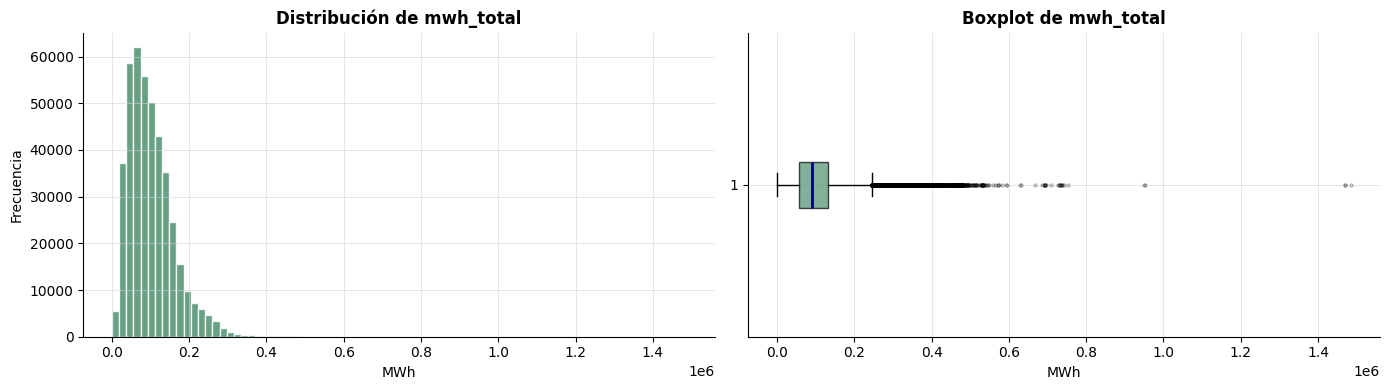

In [26]:
vals_target = df['mwh_total'].drop_nulls().to_numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(vals_target, bins=80, color='#4E8F6E', edgecolor='white', alpha=0.85)
axes[0].set_title('Distribución de mwh_total', fontweight='bold')
axes[0].set_xlabel('MWh')
axes[0].set_ylabel('Frecuencia')

axes[1].boxplot(vals_target, vert=False, patch_artist=True,
                boxprops=dict(facecolor='#4E8F6E', alpha=0.7),
                medianprops=dict(color='navy', linewidth=2),
                flierprops=dict(marker='o', markersize=2, alpha=0.3, color='#D4B93A'))
axes[1].set_title('Boxplot de mwh_total', fontweight='bold')
axes[1].set_xlabel('MWh')

plt.tight_layout()
plt.show()

In [27]:
print(f"sum(is.na(mwh_total)): {df['mwh_total'].null_count()}")


sum(is.na(mwh_total)): 0


> **Observaciones:**
> La distribución de mwh_total presenta sesgo positivo con cola derecha pronunciada. 

- La mediana está muy por debajo de la media, indicando que la mayoría de bloques tienen consumo moderado pero existen picos elevados de alta magnitud. 

- Estos outliers identificados son de 1.48 M lo cual muestra uqe estos no pueden ser datos reales.

- La desviación estándar de 59 k muestra la alta dispersión , los valores están muy dispersos.

> No se sigue una distribución normal así que se usará Spearman para correlaciones y Kruskal-Wallis / Mann-Whitney para tests de hipótesis.


#### Outliers

Detección con umbral de 5× la mediana por CP. Se usa la mediana porque no se infla por los propios outliers que intenta detectar.

In [28]:
# ── Detección: umbral 5× mediana + contexto de casos ─────────────────────────
umbrales = df.group_by("cod_postal").agg(pl.col("mwh_total").median().alias("mediana"))

print(df.join(umbrales, on="cod_postal")
    .filter(pl.col("mwh_total") > pl.col("mediana") * 5)
    .group_by("cod_postal")
    .agg(pl.len().alias("n_registros"))
    .sort("n_registros", descending=True))

# Contexto de los 3 casos erróneos del umbral mediana × 5
casos = {
    "08030 — Sostenido (may 2023)": df.filter(
        (pl.col("cod_postal") == "08030") &
        (pl.col("datetime") >= pl.datetime(2023, 5, 5)) &
        (pl.col("datetime") < pl.datetime(2023, 5, 12))
    ).select(["datetime", "mwh_total", "mwh_industria"]).sort("datetime"),
    "08037 — Puntual (nov/dic 2024, feb 2025)": df.filter(
        (pl.col("cod_postal") == "08037") &
        ((pl.col("datetime") == pl.datetime(2024, 11, 20, 0)) |
         (pl.col("datetime") == pl.datetime(2024, 12, 22, 0)) |
         (pl.col("datetime") == pl.datetime(2025, 2, 24, 0)))
    ).select(["datetime", "mwh_total", "mwh_servicios"]),
    "08022 — Parcial (may 2023)": df.filter(
        (pl.col("cod_postal") == "08022") &
        (pl.col("datetime") >= pl.datetime(2023, 5, 29)) &
        (pl.col("datetime") < pl.datetime(2023, 5, 31))
    ).select(["datetime", "mwh_total", "mwh_residencial"]).sort("datetime"),
}
for nombre, resultado in casos.items():
    print(f"\n{'='*60}\n  {nombre}\n{'='*60}")
    print(resultado)

# Casos adicionales detectados con umbral 400k
print("\n" + "="*60 + "\n  Valores > 400k\n" + "="*60)
print(df.filter(pl.col("mwh_total") > 400000)
    .select(["datetime", "cod_postal", "nombre_postal", "mwh_total"])
    .sort("mwh_total", descending=True).head(10))

for cp in ["08013", "08036", "08009", "08006", "08011", "08030"]:
    fecha_max = df.filter(pl.col("cod_postal") == cp).sort("mwh_total", descending=True).head(1)["datetime"][0]
    print(f"\n{'='*50}\nCP {cp}\n{'='*50}")
    print(df.filter(
        (pl.col("cod_postal") == cp) &
        (pl.col("datetime") >= fecha_max - pl.duration(days=3)) &
        (pl.col("datetime") <= fecha_max + pl.duration(days=3))
    ).select(["datetime", "mwh_total"]).sort("datetime"))

shape: (6, 2)
┌────────────┬─────────────┐
│ cod_postal ┆ n_registros │
│ ---        ┆ ---         │
│ str        ┆ u32         │
╞════════════╪═════════════╡
│ 08037      ┆ 450         │
│ 08009      ┆ 51          │
│ 08036      ┆ 10          │
│ 08006      ┆ 8           │
│ 08011      ┆ 5           │
│ 08022      ┆ 4           │
└────────────┴─────────────┘

  08030 — Sostenido (may 2023)
shape: (28, 3)
┌─────────────────────┬───────────┬───────────────┐
│ datetime            ┆ mwh_total ┆ mwh_industria │
│ ---                 ┆ ---       ┆ ---           │
│ datetime[μs]        ┆ f64       ┆ i64           │
╞═════════════════════╪═══════════╪═══════════════╡
│ 2023-05-05 00:00:00 ┆ 696273.0  ┆ 604699        │
│ 2023-05-05 06:00:00 ┆ 529464.0  ┆ 379442        │
│ 2023-05-05 12:00:00 ┆ 733625.0  ┆ 562245        │
│ 2023-05-05 18:00:00 ┆ 474837.0  ┆ 313451        │
│ 2023-05-06 00:00:00 ┆ 694591.0  ┆ 600889        │
│ 2023-05-06 06:00:00 ┆ 730729.0  ┆ 595781        │
│ 2023-05-06 12:00:

**Errores de reporte — se imputan con mediana histórica 2022-2024:**

- **08030 (5–11 may 2023, 28 bloques):** `mwh_industria` de 6-12× el habitual (~50k) durante 7 días consecutivos. Caída brusca al día siguiente sin gradualidad — fallo de acumulación en reporte.
- **08037 (nov-2024/dic-2024/feb-2025, 3 bloques):** `mwh_servicios` de 1.46M vs ~35k habitual. Patrón idéntico en los 3 casos en el mismo bloque horario (00:00h) — posible error de acumulación periódica.
- **08022 (29–30 may 2023, 6 bloques):** bloques 00:00h normales pero 06:00, 12:00 y 18:00h inflados 10-15×. Posible error de distribución del consumo diario entre bloques.
- **08030 (9 ene 2025, 4 bloques):** salto abrupto de ~300k a 558-595k en un solo día sin contexto climático que lo justifique. Vuelta a normal al día siguiente.
- **08037 (jul–nov 2025, ~475 bloques):** todos los sectores 6-7× el histórico (~80-92k MWh) durante 5 meses consecutivos. Imposible atribuirlo a demanda real.
- **08009 (2 jun 2025, 4 bloques):** todos los sectores inflados proporcionalmente (~7× habitual) en un único día. Sin contexto climático ni evento que lo justifique.

**Picos reales — se mantienen:**

- **08013 (jul 2025):** crecimiento gradual durante varios días (~563k máx). Patrón consistente con ola de calor de inicio de verano.
- **08036 (ago 2023):** valores sostenidos 3-4 días (~535k máx). Gradualidad clara de subida y bajada, consistente con ola de calor.
- **08006 (jul 2025):** pico de 4-5 días con valores crecientes y decrecientes. Mismo patrón de ola de calor que 08013.
- **08011 (ene 2020):** valores altos sostenidos durante más de una semana. Patrón consistente con ola de frío invernal.

In [29]:
#### Imputación de Outliers
# Funciones de imputación por mediana histórica (2022-2024)

def imputar_sector(df, cp, sector, filtro, keys=["hora", "mes"]):
    """Imputa un sector específico con mediana histórica excluyendo el periodo erróneo."""
    med = (
        df.filter((pl.col("cod_postal") == cp) & ~filtro)
        .group_by(keys)
        .agg(pl.col(sector).median().alias("_med"))
    )
    return (df.join(med, on=keys, how="left")
        .with_columns(
            pl.when((pl.col("cod_postal") == cp) & filtro)
              .then(pl.col("_med")).otherwise(pl.col(sector)).alias(sector)
        ).drop("_med"))

def imputar_todos_sectores(df, cp, cond, anios_ref, mes_ref, keys=["hora"]):
    """Imputa todos los sectores con mediana histórica por referencia de años."""
    mes_filter = pl.col("mes").is_in(mes_ref) if isinstance(mes_ref, list) else pl.col("mes") == mes_ref
    med = (
        df.filter((pl.col("cod_postal") == cp) & pl.col("anio").is_in(anios_ref) & mes_filter)
        .group_by(keys)
        .agg([pl.col("mwh_industria").median().alias("_ind"),
              pl.col("mwh_residencial").median().alias("_res"),
              pl.col("mwh_servicios").median().alias("_ser")])
    )
    return (df.join(med, on=keys, how="left")
        .with_columns([
            pl.when(cond).then(pl.col("_ind")).otherwise(pl.col("mwh_industria")).alias("mwh_industria"),
            pl.when(cond).then(pl.col("_res")).otherwise(pl.col("mwh_residencial")).alias("mwh_residencial"),
            pl.when(cond).then(pl.col("_ser")).otherwise(pl.col("mwh_servicios")).alias("mwh_servicios"),
        ]).drop(["_ind", "_res", "_ser"]))

# 08030 — mwh_industria, 5-11 may 2023 (28 bloques)
df = imputar_sector(df, "08030", "mwh_industria",
    (pl.col("datetime") >= pl.datetime(2023, 5, 5)) & (pl.col("datetime") < pl.datetime(2023, 5, 12)))

# 08037 — mwh_servicios, 3 bloques puntuales
df = imputar_sector(df, "08037", "mwh_servicios",
    (pl.col("datetime") == pl.datetime(2024, 11, 20, 0)) |
    (pl.col("datetime") == pl.datetime(2024, 12, 22, 0)) |
    (pl.col("datetime") == pl.datetime(2025, 2, 24, 0)))

# 08022 — mwh_residencial, 29-30 may 2023 (6 bloques)
df = imputar_sector(df, "08022", "mwh_residencial",
    (pl.col("datetime") >= pl.datetime(2023, 5, 29)) & (pl.col("datetime") < pl.datetime(2023, 5, 31)))

# 08030 — todos sectores, 9 ene 2025 (4 bloques)
df = imputar_todos_sectores(df, "08030",
    cond=(pl.col("cod_postal") == "08030") & (pl.col("datetime").dt.date() == pl.date(2025, 1, 9)),
    anios_ref=[2022, 2023, 2024], mes_ref=1)

# 08037 — todos sectores, jul-nov 2025 (~475 bloques, umbral > 100k)
df = imputar_todos_sectores(df, "08037",
    cond=(pl.col("cod_postal") == "08037") & (pl.col("anio") == 2025) &
         (pl.col("mes").is_in([7, 8, 9, 10, 11])) & (pl.col("mwh_total") > 100000),
    anios_ref=[2022, 2023, 2024], mes_ref=[7, 8, 9, 10, 11], keys=["hora", "mes", "dia_semana"])

# Fix mwh_no_especificado anómalo en 08037 (nunca tuvo este sector en histórico)
df = df.with_columns(
    pl.when((pl.col("cod_postal") == "08037") & (pl.col("anio") == 2025) &
            (pl.col("mes").is_in([7, 8, 9, 10, 11])) & (pl.col("mwh_no_especificado").is_not_null()))
    .then(pl.lit(None).cast(pl.Int64))
    .otherwise(pl.col("mwh_no_especificado"))
    .alias("mwh_no_especificado")
)

# 08009 — todos sectores, 2 jun 2025 (4 bloques)
df = imputar_todos_sectores(df, "08009",
    cond=(pl.col("cod_postal") == "08009") & (pl.col("datetime").dt.date() == pl.date(2025, 6, 2)),
    anios_ref=[2022, 2023, 2024], mes_ref=6)

print("Todos los outliers positivos imputados")

Todos los outliers positivos imputados


Valores > 400k restantes: 290
shape: (20, 7)
┌──────────────┬────────────┬──────────────┬───────────┬──────────────┬──────────────┬─────────────┐
│ datetime     ┆ cod_postal ┆ nombre_posta ┆ mwh_total ┆ mwh_industri ┆ mwh_residenc ┆ mwh_servici │
│ ---          ┆ ---        ┆ l            ┆ ---       ┆ a            ┆ ial          ┆ os          │
│ datetime[μs] ┆ str        ┆ ---          ┆ f64       ┆ ---          ┆ ---          ┆ ---         │
│              ┆            ┆ str          ┆           ┆ f64          ┆ f64          ┆ f64         │
╞══════════════╪════════════╪══════════════╪═══════════╪══════════════╪══════════════╪═════════════╡
│ 2025-07-02   ┆ 08013      ┆ La Sagrada   ┆ 563018.0  ┆ 9070.0       ┆ 242277.0     ┆ 311671.0    │
│ 12:00:00     ┆            ┆ Família      ┆           ┆              ┆              ┆             │
│ 2023-08-24   ┆ 08036      ┆ L'Antiga     ┆ 535033.0  ┆ 7951.0       ┆ 133672.0     ┆ 393410.0    │
│ 12:00:00     ┆            ┆ Esquerra de  ┆  

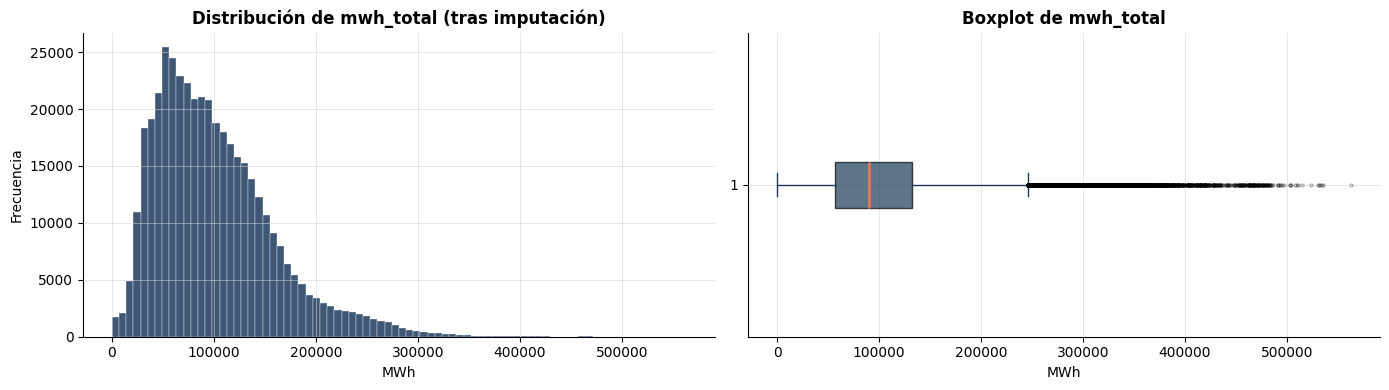

In [30]:
# Recálculo mwh_total + verificación final
df = df.with_columns(
    (pl.col("mwh_industria").fill_null(0) + pl.col("mwh_residencial").fill_null(0) +
     pl.col("mwh_servicios").fill_null(0) + pl.col("mwh_no_especificado").fill_null(0)
    ).alias("mwh_total")
)

print(f"Valores > 400k restantes: {df.filter(pl.col('mwh_total') > 400000).shape[0]}")
print(df.filter(pl.col("mwh_total") > 400000)
    .select(["datetime", "cod_postal", "nombre_postal", "mwh_total", "mwh_industria", "mwh_residencial", "mwh_servicios"])
    .sort("mwh_total", descending=True).head(20))

vals_target = df['mwh_total'].drop_nulls().to_numpy()
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(vals_target, bins=80, color='#1B3A5C', edgecolor='white', linewidth=0.3, alpha=0.85)
axes[0].set_title('Distribución de mwh_total (tras imputación)', fontweight='bold')
axes[0].set_xlabel('MWh'); axes[0].set_ylabel('Frecuencia')
axes[1].boxplot(vals_target, vert=False, patch_artist=True,
                boxprops=dict(facecolor='#1B3A5C', alpha=0.7),
                medianprops=dict(color='#E07B5A', linewidth=2),
                flierprops=dict(marker='o', markersize=2, alpha=0.3, color='#1B3A5C'),
                whiskerprops=dict(color='#1B3A5C'), capprops=dict(color='#1B3A5C'))
axes[1].set_title('Boxplot de mwh_total', fontweight='bold')
axes[1].set_xlabel('MWh')
plt.tight_layout(); plt.show()

> Tras imputar los 520 registros erróneos con mediana histórica (2022-2024), la distribución muestra una forma log-normal coherente con el comportamiento esperado del consumo eléctrico urbano. La mayoría de bloques se concentran entre 20k–150k MWh, con una cola derecha moderada que refleja los picos reales de demanda estival. Los valores máximos legítimos (olas de calor 08013, 08036, 08006; ola de frío 08011) se mantienen como parte de la variabilidad natural del sistema.

## Descomposición de consumo energético

In [31]:
(
    df.group_by("cod_postal")
    .agg([
        pl.col("mwh_industria").sum(),
        pl.col("mwh_residencial").sum(),
        pl.col("mwh_servicios").sum(),
        pl.col("mwh_no_especificado").sum(),
    ])
    .with_columns([
        (pl.col("mwh_industria") / (pl.col("mwh_industria") + pl.col("mwh_residencial") + pl.col("mwh_servicios")) * 100).round(1).alias("pct_industria"),
        (pl.col("mwh_residencial") / (pl.col("mwh_industria") + pl.col("mwh_residencial") + pl.col("mwh_servicios")) * 100).round(1).alias("pct_residencial"),
        (pl.col("mwh_servicios") / (pl.col("mwh_industria") + pl.col("mwh_residencial") + pl.col("mwh_servicios")) * 100).round(1).alias("pct_servicios"),
    ])
    .select(["cod_postal", "pct_industria", "pct_residencial", "pct_servicios"])
    .sort("pct_industria", descending=True)
)

cod_postal,pct_industria,pct_residencial,pct_servicios
str,f64,f64,f64
"""08039""",41.5,3.3,55.3
"""08004""",38.8,26.8,34.5
"""08038""",36.7,21.2,42.0
"""08040""",29.0,5.6,65.4
"""08030""",16.0,27.0,57.1
"""08018""",10.4,32.2,57.4
"""08020""",7.2,31.9,60.9
"""08019""",5.8,47.3,46.9
"""08021""",4.0,45.3,50.6


mwh_total es una variable compuesta, es la suma de consumo industrial, residencial, de servicios y no especificado. 

Ningún código postal tiene un perfil puro: 

- servicios domina en 38 de 42 CPs, siendo el sector principal en toda Barcelona. 

- La industria solo es relevante en 3-4 CPs (08039, 08004, 08038).

- Residencial alcanza su máximo en zonas periféricas como 08032 (70%). Esta composición explica por qué los patrones temporales difieren entre barrios, un CP con alto peso industrial será más probable en tener picos en horario laboral de lunes a viernes, mientras uno con alto peso residencial mostrará picos vespertinos y mayor consumo en fin de semana. 

El modelo que cree deberá capturar estas diferencias de perfil entre CPs, no solo la magnitud del consumo.

#### Serie Temporal de mwh

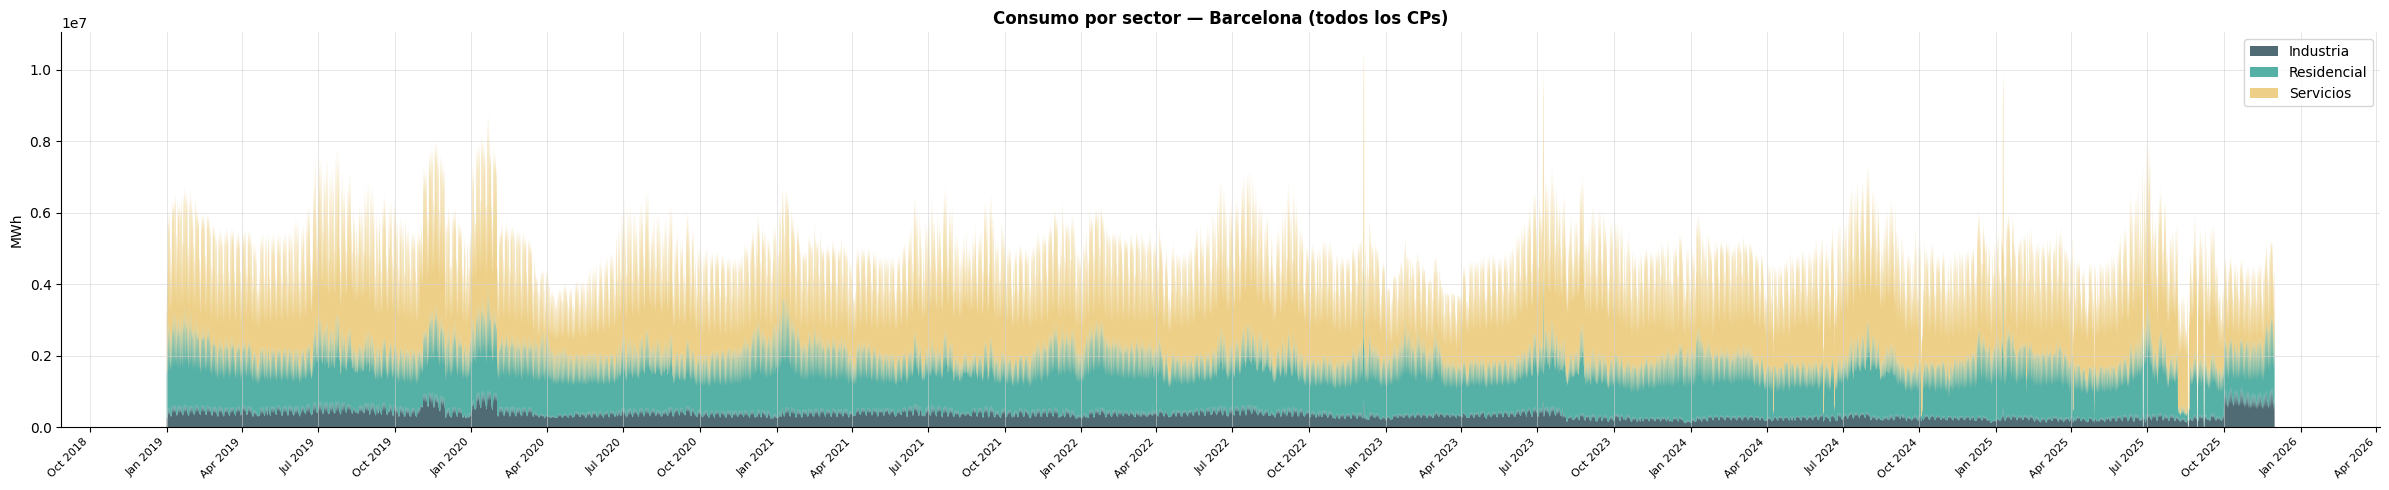

In [32]:
# Serie temporal global — suma de todos los CPs
import matplotlib.dates as mdates

serie_global = (
    df.group_by("datetime")
    .agg([
        pl.col("mwh_industria").sum(),
        pl.col("mwh_residencial").sum(),
        pl.col("mwh_servicios").sum(),
    ])
    .sort("datetime")
)

fechas = serie_global["datetime"].to_numpy()
ind    = serie_global["mwh_industria"].to_numpy()
res    = serie_global["mwh_residencial"].to_numpy()
ser    = serie_global["mwh_servicios"].to_numpy()

fig, ax = plt.subplots(figsize=(24, 5))
ax.stackplot(fechas, ind, res, ser,
             labels=["Industria", "Residencial", "Servicios"],
             colors=["#264653", "#2A9D8F", "#E9C46A"],
             alpha=0.8)
ax.set_title("Consumo por sector — Barcelona (todos los CPs)", fontweight="bold")
ax.set_ylabel("MWh")
ax.legend(loc="upper right")
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.tight_layout()
plt.show()

> El consumo eléctrico de Barcelona muestra una estacionalidad anual clara con picos en verano (julio–agosto) y en invierno (diciembre–enero), consistente con el efecto combinado de aire acondicionado y calefacción. Los servicios dominan el consumo en todos los períodos, seguidos del residencial. La industria tiene un peso marginal y estable.

> Se observa una caída notable en 2020 (COVID-19) y una recuperación progresiva hasta 2022. A partir de 2023 el consumo se estabiliza con niveles ligeramente superiores al período pre-pandemia.

In [33]:
(df.group_by(["cod_postal", "nombre_postal"])
 .agg([
     pl.len().alias("n_registros"),
     pl.col("mwh_total").null_count().alias("nulls"),
     pl.col("mwh_total").mean().alias("mwh_mean"),
     pl.col("mwh_industria").sum().alias("sum_industria"),
     pl.col("mwh_residencial").sum().alias("sum_residencial"),
     pl.col("mwh_servicios").sum().alias("sum_servicios"),
     pl.col("mwh_total").sum().alias("sum_total"),
 ])
 .with_columns([
     ((pl.col("sum_industria") / pl.col("sum_total") * 100).round(1).cast(pl.Utf8) + pl.lit("%")).alias("pct_industria"),
     ((pl.col("sum_residencial") / pl.col("sum_total") * 100).round(1).cast(pl.Utf8) + pl.lit("%")).alias("pct_residencial"),
     ((pl.col("sum_servicios") / pl.col("sum_total") * 100).round(1).cast(pl.Utf8) + pl.lit("%")).alias("pct_servicios"),
 ])
 .drop(["sum_industria", "sum_residencial", "sum_servicios", "sum_total"])
 .sort("mwh_mean", descending=True)
)

cod_postal,nombre_postal,n_registros,nulls,mwh_mean,pct_industria,pct_residencial,pct_servicios
str,str,u32,u32,f64,str,str,str
"""08040""","""La Zona Franca""",10100,0,233424.701881,"""29.0%""","""5.6%""","""65.3%"""
"""08030""","""El Bon Pastor / Sant Andreu""",10100,0,211600.899257,"""16.0%""","""26.9%""","""57.0%"""
"""08028""","""Zona Universitària / Les Corts""",10100,0,185543.360099,"""2.4%""","""36.9%""","""60.6%"""
"""08038""","""Montjuïc / Zona Franca""",10100,0,161045.791287,"""36.7%""","""21.2%""","""42.0%"""
"""08018""","""Fort Pienc""",10100,0,150034.722475,"""10.4%""","""32.1%""","""57.2%"""
"""08029""","""Nova Esquerra de l'Eixample""",10100,0,139209.444554,"""2.2%""","""42.8%""","""55.0%"""
"""08003""","""La Barceloneta""",10100,0,133936.397723,"""2.4%""","""29.0%""","""68.6%"""
"""08004""","""Montjuïc / Poble Sec""",10100,0,133934.311584,"""38.8%""","""26.8%""","""34.5%"""
"""08014""","""Sants - Montjuïc""",10100,0,133366.916436,"""2.3%""","""39.5%""","""58.1%"""


Se seleccionan 4 códigos postales representativos de perfiles de consumo distintos,
con cobertura completa (10.104 registros) y mínimos nulos:

- **08038 Montjuïc / Zona Franca**  por perfil industrial (36.7% industria), mayor proporción del dataset
- **08005 El Poblenou** por perfil mixto equilibrado, referente en literatura smart city Barcelona, 4 nulos
- **08032 El Carmel / El Guinardó** — perfil residencial dominante (70.3% residencial)
- **08002 Barri Gòtic** por perfil servicios/turístico (75.6% servicios), consumo estacional marcado

In [34]:
CPS = {
    "08038": "Montjuïc / Zona Franca (Industrial)",
    "08005": "El Poblenou (Mixto)",
    "08032": "El Carmel / El Guinardó (Residencial)",
    "08002": "Barri Gòtic (Servicios/Turístico)",
}

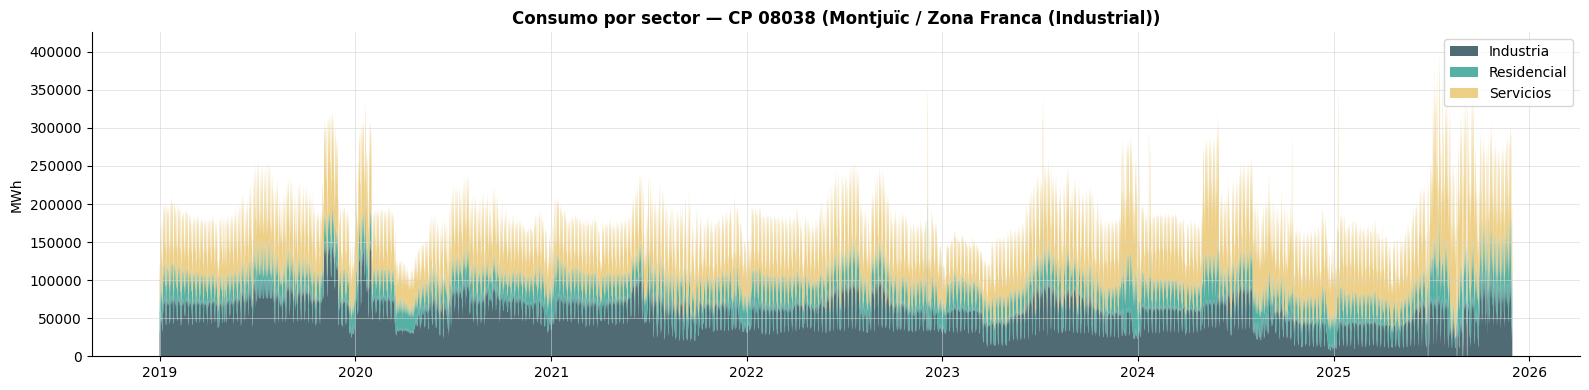

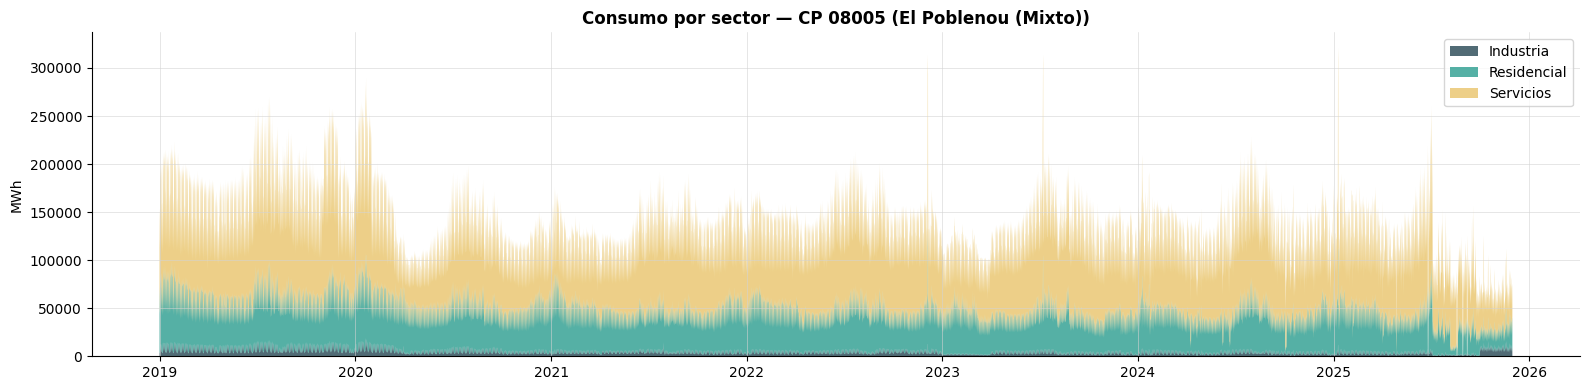

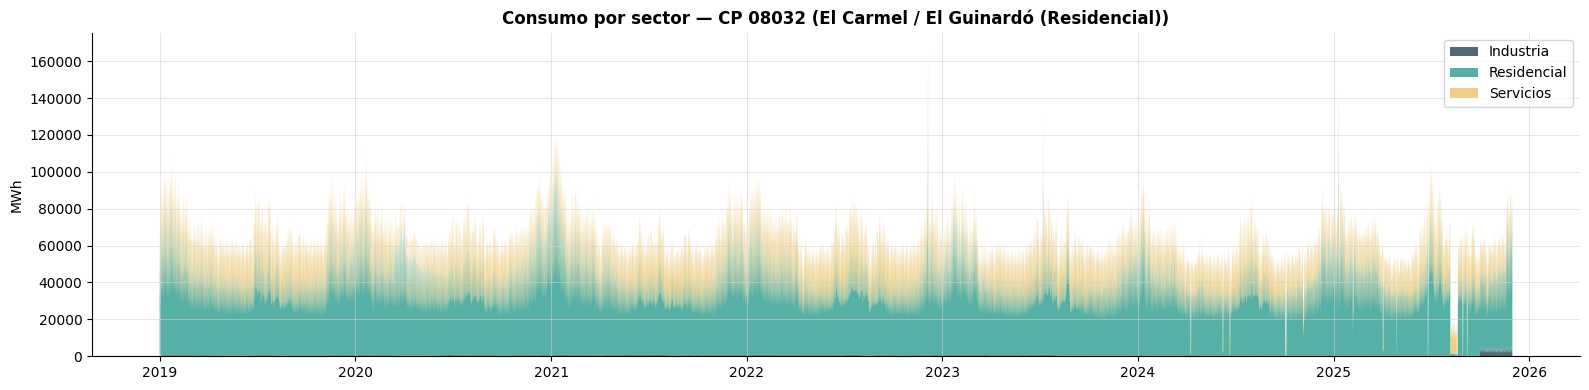

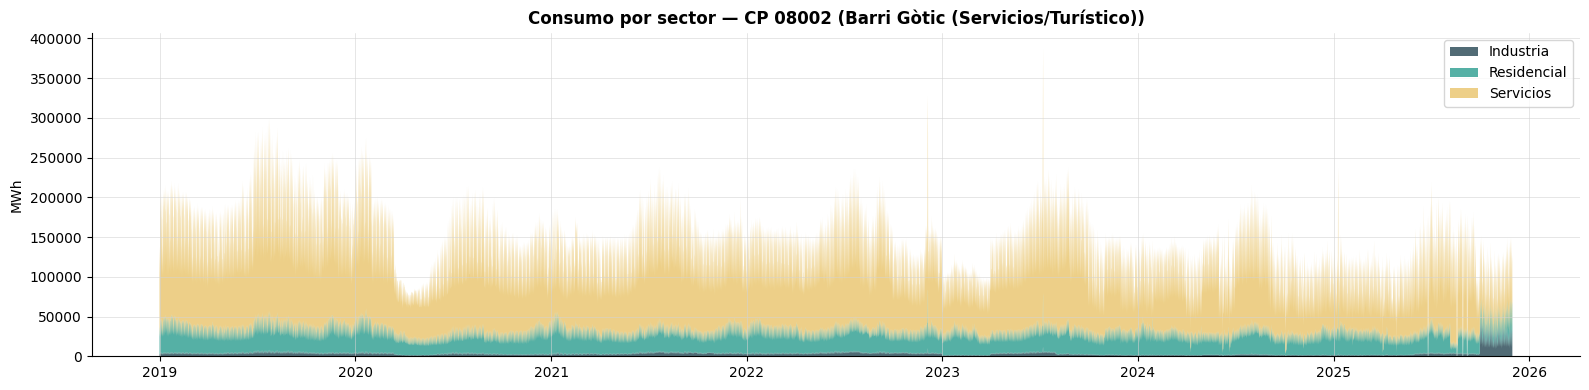

In [35]:
for cp, nombre in CPS.items():
    serie_cp = (
        df.filter(pl.col("cod_postal") == cp)
        .sort("datetime")
        .select(["datetime", "mwh_industria", "mwh_residencial", "mwh_servicios"])
    )

    fechas = serie_cp["datetime"].to_numpy()
    ind    = serie_cp["mwh_industria"].to_numpy()
    res    = serie_cp["mwh_residencial"].to_numpy()
    ser    = serie_cp["mwh_servicios"].to_numpy()

    fig, ax = plt.subplots(figsize=(16, 4))
    ax.stackplot(fechas, ind, res, ser,
                 labels=["Industria", "Residencial", "Servicios"],
                 colors=["#264653", "#2A9D8F", "#E9C46A"],
                 alpha=0.8)
    ax.set_title(f"Consumo por sector — CP {cp} ({nombre})", fontweight="bold")
    ax.set_ylabel("MWh")
    ax.legend(loc="upper right")
    plt.tight_layout()
    plt.show()

> **Observaciones iniciales — Consumo por sector**
 
> - 08038 Zona Franca: perfil industrial visible y sostenido. Pico 2020 probablemente asociado a actividad que no se detuvieron durante el confinamiento.
> - 08005 El Poblenou servicios domina sobre industria y residencial, reflejo de la reconversión del distrito hacia tecnología y oficinas.
> - 08032 El Carmel balance residencial-servicios con industria casi nula. Aparente estacionalidad de verano muy marcada.
> - 08002 Barri Gòtic servicios aplastante. El desplome de 2020–2021 es el más pronunciado de los 4 CPs, señal directa del impacto del COVID en el turismo.

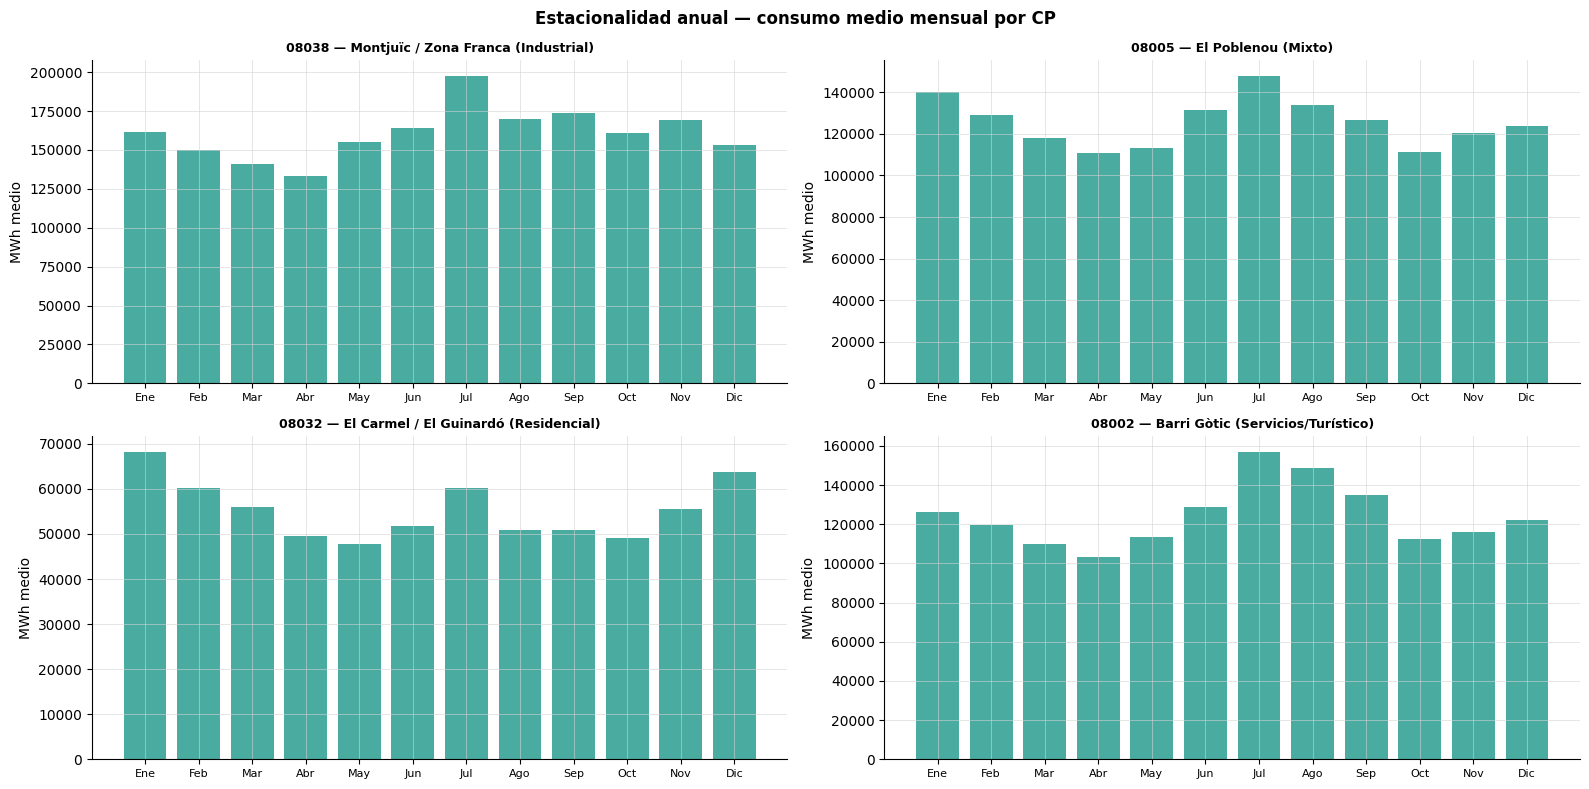

In [36]:
fig, axes = plt.subplots(2, 2, figsize=(16, 8), sharey=False)
fig.suptitle("Estacionalidad anual — consumo medio mensual por CP", fontweight="bold")

meses = ["Ene", "Feb", "Mar", "Abr", "May", "Jun",
         "Jul", "Ago", "Sep", "Oct", "Nov", "Dic"]

for ax, (cp, nombre) in zip(axes.flatten(), CPS.items()):
    mensual = (
        df.filter(
            (pl.col("cod_postal") == cp) &
            (pl.col("anio") < 2026)
        )
        .group_by("mes")
        .agg(pl.col("mwh_total").mean().alias("mwh_medio"))
        .sort("mes")
    )

    ax.bar(mensual["mes"].to_numpy(), mensual["mwh_medio"].to_numpy(),
           color="#2A9D8F", alpha=0.85)
    ax.set_title(f"{cp} — {nombre}", fontsize=9, fontweight="bold")
    ax.set_ylabel("MWh medio")
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(meses, fontsize=8)

plt.tight_layout()
plt.show()

> Los 4 CPs muestran patrones estacionales distintos según su perfil de consumo.
- Industrial (08038) y turístico (08002) pican en julio-agosto con 195k y 155k MWh respectivamente con caídas en marzo-abril, patrón consistente con mayor actividad de temporada y demanda de climatización.
- El residencial (08032) invierte el patrón: picos en enero y diciembre 65k MWh y mínimos en abril-mayo (48k MWh), sugiriendo mayor dependencia de calefacción que de refrigeración.
- El mixto (08005) se mantiene más estable a lo largo del año con un pico moderado en julio-agosto (150k MWh) y un segundo repunte en enero por consumo invernal.
- En magnitud absoluta, Zona Franca lidera con diferencia mientras El Carmel se mantiene en el rango más bajo al carecer de actividad industrial o turística significativa.

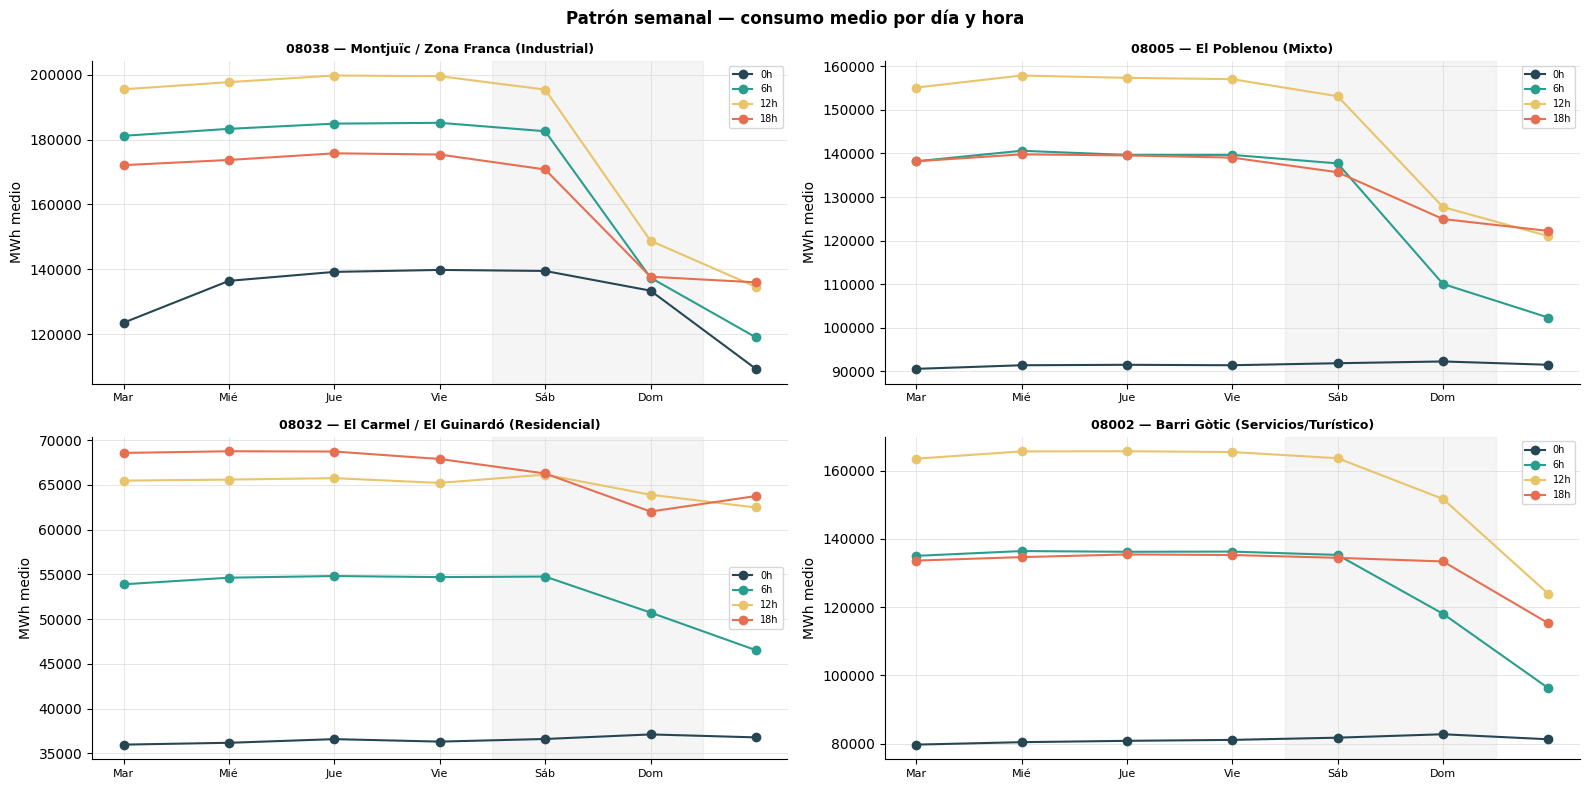

In [37]:
fig, axes = plt.subplots(2, 2, figsize=(16, 8), sharey=False)
fig.suptitle("Patrón semanal — consumo medio por día y hora", fontweight="bold")

dias = ["Lun", "Mar", "Mié", "Jue", "Vie", "Sáb", "Dom"]

for ax, (cp, nombre) in zip(axes.flatten(), CPS.items()):
    semanal = (
        df.filter(pl.col("cod_postal") == cp)
        .group_by(["dia_semana", "hora"])
        .agg(pl.col("mwh_total").mean().alias("mwh_medio"))
        .sort(["dia_semana", "hora"])
    )

    for hora_val, color in zip([0, 6, 12, 18], ["#264653", "#2A9D8F", "#E9C46A", "#E76F51"]):
        subset = semanal.filter(pl.col("hora") == hora_val)
        ax.plot(subset["dia_semana"].to_numpy(),
                subset["mwh_medio"].to_numpy(),
                marker="o", label=f"{hora_val}h", color=color)

    ax.set_title(f"{cp} — {nombre}", fontsize=9, fontweight="bold")
    ax.set_ylabel("MWh medio")
    ax.set_xticks(range(7))
    ax.set_xticklabels(dias, fontsize=8)
    ax.legend(fontsize=7)
    ax.axvspan(4.5, 6.5, alpha=0.08, color="gray", label="Fin de semana")

plt.tight_layout()
plt.show()

> El patrón semanal revela diferencias claras entre perfiles. 

- La Zona Franca (08038) registra la caída más pronunciada en fin de semana, con descensos de 60k MWh en los bloques 6h y 12h del domingo respecto a los días laborables, señal directa de paralización de actividad industrial. El Barri Gòtic (08002) también cae en domingo pero mantiene el bloque 18h elevado, coherente con actividad de restauración y ocio nocturno que no para el fin de semana.
- El Carmel (08032) es el más estable a lo largo de la semana: la diferencia entre martes y domingo es mínima (5k MWh), confirmando que el consumo residencial no
  responde al calendario laboral. El Poblenou (08005) presenta un comportamiento intermedio con caída moderada en fin de semana.
- En cuanto a magnitudes, Zona Franca lidera con bloques de 12h que superan los 200k MWh en días laborables, seguida de Barri Gòtic (165k MWh) y Poblenou
  (158k MWh). El Carmel se mantiene muy por debajo (~69k MWh en 18h), reflejo
  de su perfil mayoritariamente residencial.
- En todos los CPs el bloque 12h concentra el mayor consumo y el 0h el mínimo, confirmando el patrón intradiario como una de las señales más predictivas del dataset.

> Conlsuciones de decomposición de consumo:

- Los patrones temporales confirman que el consumo eléctrico en Barcelona responde a tres ciclos superpuestos: 
    - intradiario (pico 12h, valle 0h)
    - semanal (caída en fin de semana variable según perfil)
    - anual con:
        - pico verano en industrial y turístico
        - pico invierno en residencial.
- Estos ciclos son consistentes y repetibles, lo que valida la viabilidad del forecasting: si el consumo fuera aleatorio, predecir sería imposible. La señal estructural existe y es suficientemente fuerte.
- La diferencia de comportamiento entre perfiles (industrial, residencial, turístico) confirma que cod_postal y la composición sectorial son features clave para el modelo ya que sin ellas, el modelo confundiría patrones de barrios con dinámicas completamente distintas.
- Las variables de calendario (hora, dia_semana, mes, es_finde, es_festivo) ya presentes en el dataset son directamente justificadas por este análisis como features de alta importancia esperada para el modelado

### Decomposición STL

#### Decomposición STL Barrio Gotic Residencial- SERVICIOS

In [38]:
cp = "08032"
serie_cp = (
    df.filter(pl.col("cod_postal") == cp)
    .sort("datetime")
    .select(["datetime", "mwh_total"])
)

fechas     = serie_cp["datetime"].to_numpy()
serie_vals = serie_cp["mwh_total"].to_numpy()

In [39]:
print(
    df.filter(
        (pl.col("cod_postal") == "08032") &
        (pl.col("datetime") >= pl.datetime(2025, 7, 1)) &
        (pl.col("datetime") < pl.datetime(2025, 11, 1))
    )
    .select(["datetime", "mwh_total", "mwh_industria", "mwh_residencial", "mwh_servicios"])
    .sort("mwh_total")
    .head(20)
)

shape: (20, 5)
┌─────────────────────┬───────────┬───────────────┬─────────────────┬───────────────┐
│ datetime            ┆ mwh_total ┆ mwh_industria ┆ mwh_residencial ┆ mwh_servicios │
│ ---                 ┆ ---       ┆ ---           ┆ ---             ┆ ---           │
│ datetime[μs]        ┆ f64       ┆ f64           ┆ f64             ┆ f64           │
╞═════════════════════╪═══════════╪═══════════════╪═════════════════╪═══════════════╡
│ 2025-08-19 00:00:00 ┆ 0.0       ┆ 0.0           ┆ 0.0             ┆ 0.0           │
│ 2025-08-30 00:00:00 ┆ 0.0       ┆ 0.0           ┆ 0.0             ┆ 0.0           │
│ 2025-09-07 00:00:00 ┆ 0.0       ┆ 0.0           ┆ 0.0             ┆ 0.0           │
│ 2025-08-19 06:00:00 ┆ 0.0       ┆ 0.0           ┆ 0.0             ┆ 0.0           │
│ 2025-08-30 06:00:00 ┆ 0.0       ┆ 0.0           ┆ 0.0             ┆ 0.0           │
│ 2025-09-07 06:00:00 ┆ 0.0       ┆ 0.0           ┆ 0.0             ┆ 0.0           │
│ 2025-08-19 12:00:00 ┆ 0.0       ┆ 0.0

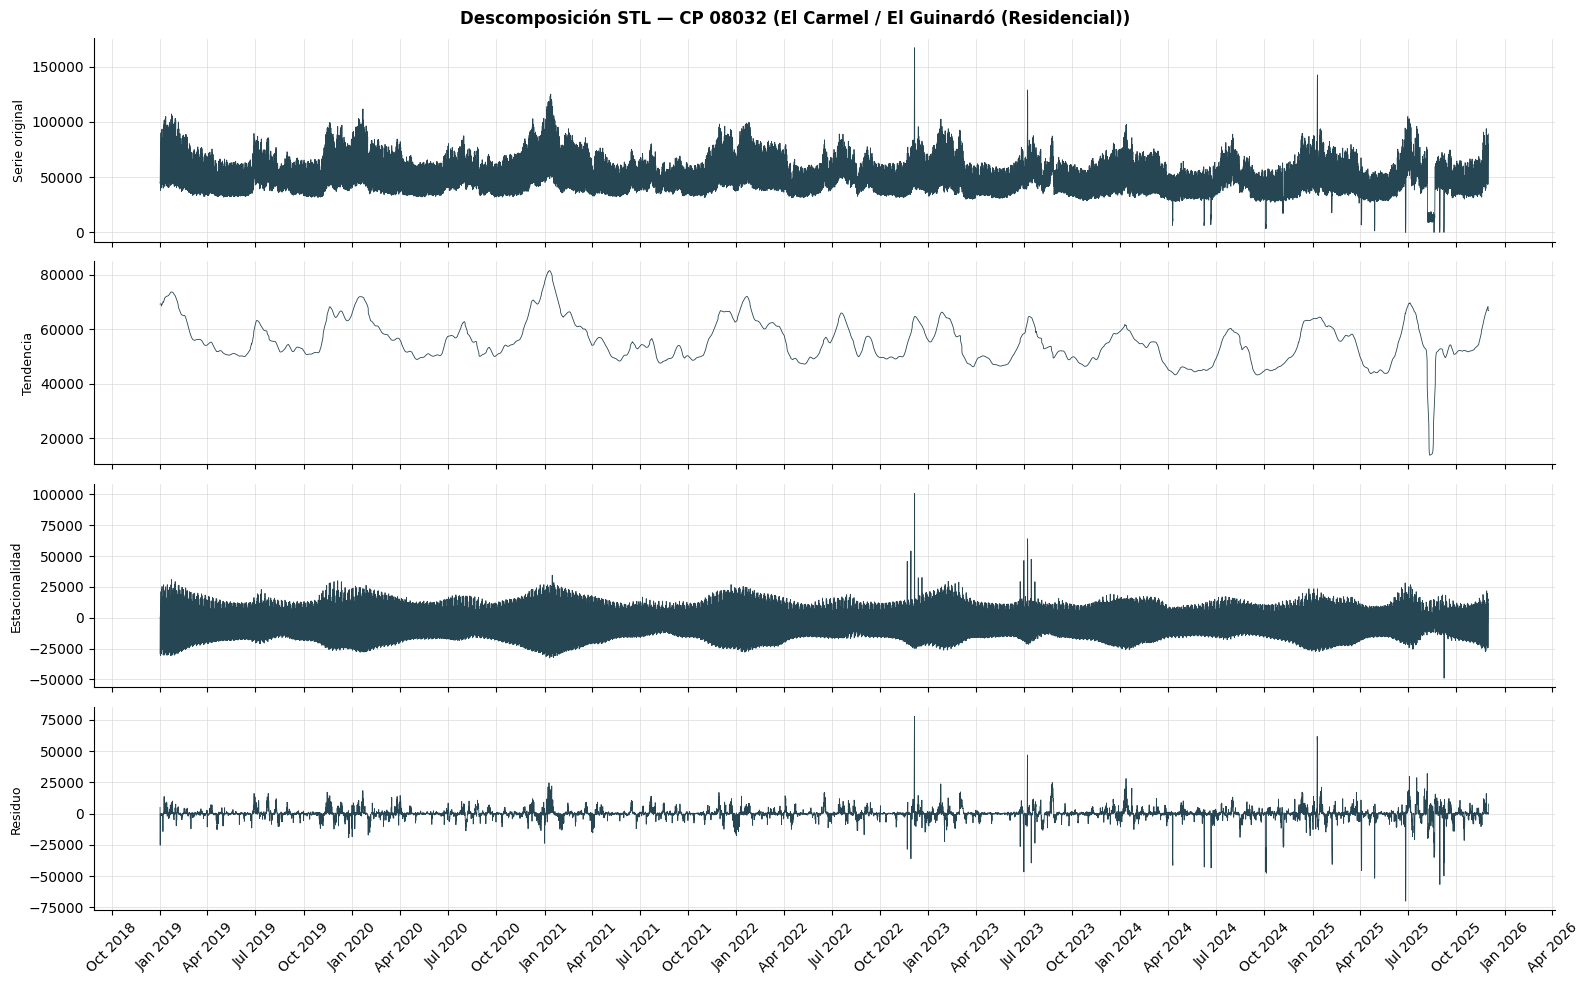

In [40]:
import matplotlib.dates as mdates

res = STL(serie_vals, period=28, robust=True).fit()

fig, axes = plt.subplots(4, 1, figsize=(16, 10), sharex=True)
fig.suptitle(f"Descomposición STL — CP {cp} ({CPS[cp]})", fontweight="bold")

for ax, (nombre_comp, vals) in zip(axes, {
    "Serie original": serie_vals,
    "Tendencia":      res.trend,
    "Estacionalidad": res.seasonal,
    "Residuo":        res.resid,
}.items()):
    ax.plot(fechas, vals, color="#264653", linewidth=0.6)
    ax.set_ylabel(nombre_comp, fontsize=9)
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

- La descomposición STL del Barri Gòtic (08002) revela una serie con estructura predecible pero con picos externos importantes. La tendencia muestra el impacto más pronunciado del COVID de los 4 CPs analizados: caída desde 200k hasta 100k MWh, entre enero y abril 2020, reflejo directo del colapso del turismo y la actividad comercial. La recuperación fue gradual y no se completó hasta 2023.
- La estacionalidad capturada corresponde al ciclo semanal (period=28). El ciclo anual queda absorbido en la tendencia como ondulaciones lentas recurrentes. En el Barri Gòtic, al ser un perfil de servicios/turístico, el pico anual se concentra en verano sin un repunte invernal significativo. Este comportamiento contrasta con lo esperado en perfiles residenciales como El Carmel (08032), donde la tendencia debería mostrar picos en enero-diciembre por calefacción.
- La estacionalidad semanal es clara y consistente, con amplitud variable: más pronunciada en verano oscilando 50k MWh cuando la actividad turística intensifica los contrastes entre bloques horarios. 
- El residuo se mantiene cercano a 0 la mayor parte del tiempo, con picos puntuales en 2022-2024 atribuibles a eventos masivos no recurrentes (Tal vez conciertos o festivales). Esto confirma que la serie tiene estructura predecible y que los errores del modelo se concentrarán en eventos atípicos difíciles de anticipar sin información externa.

#### Decomposición STL resto de barrios

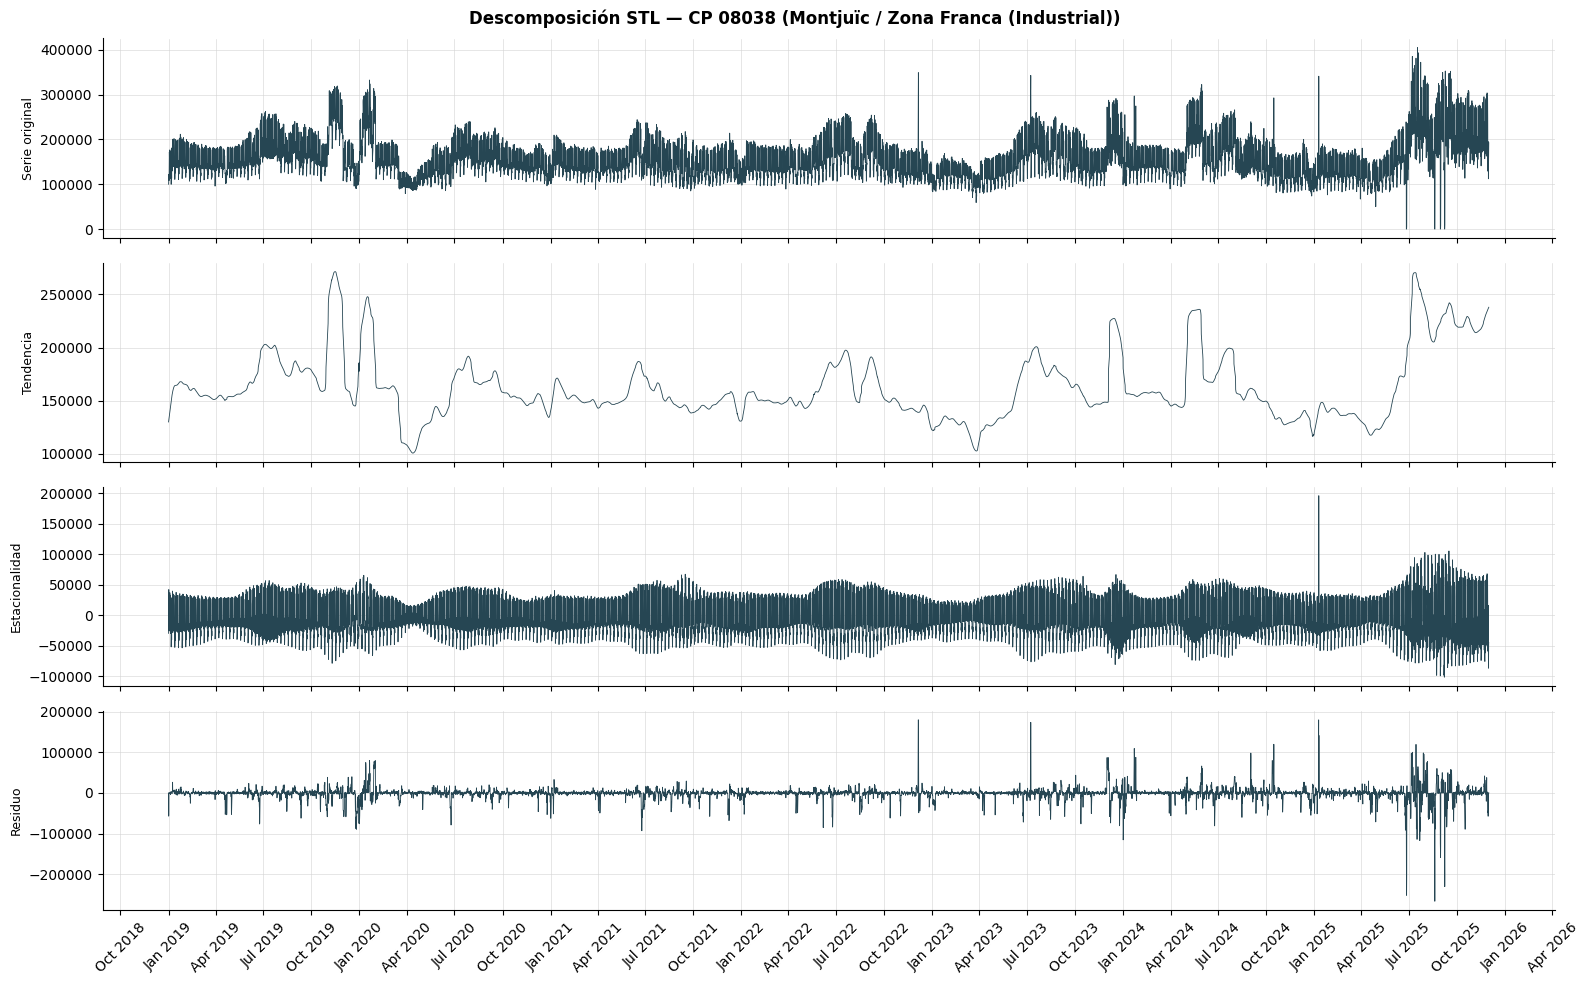

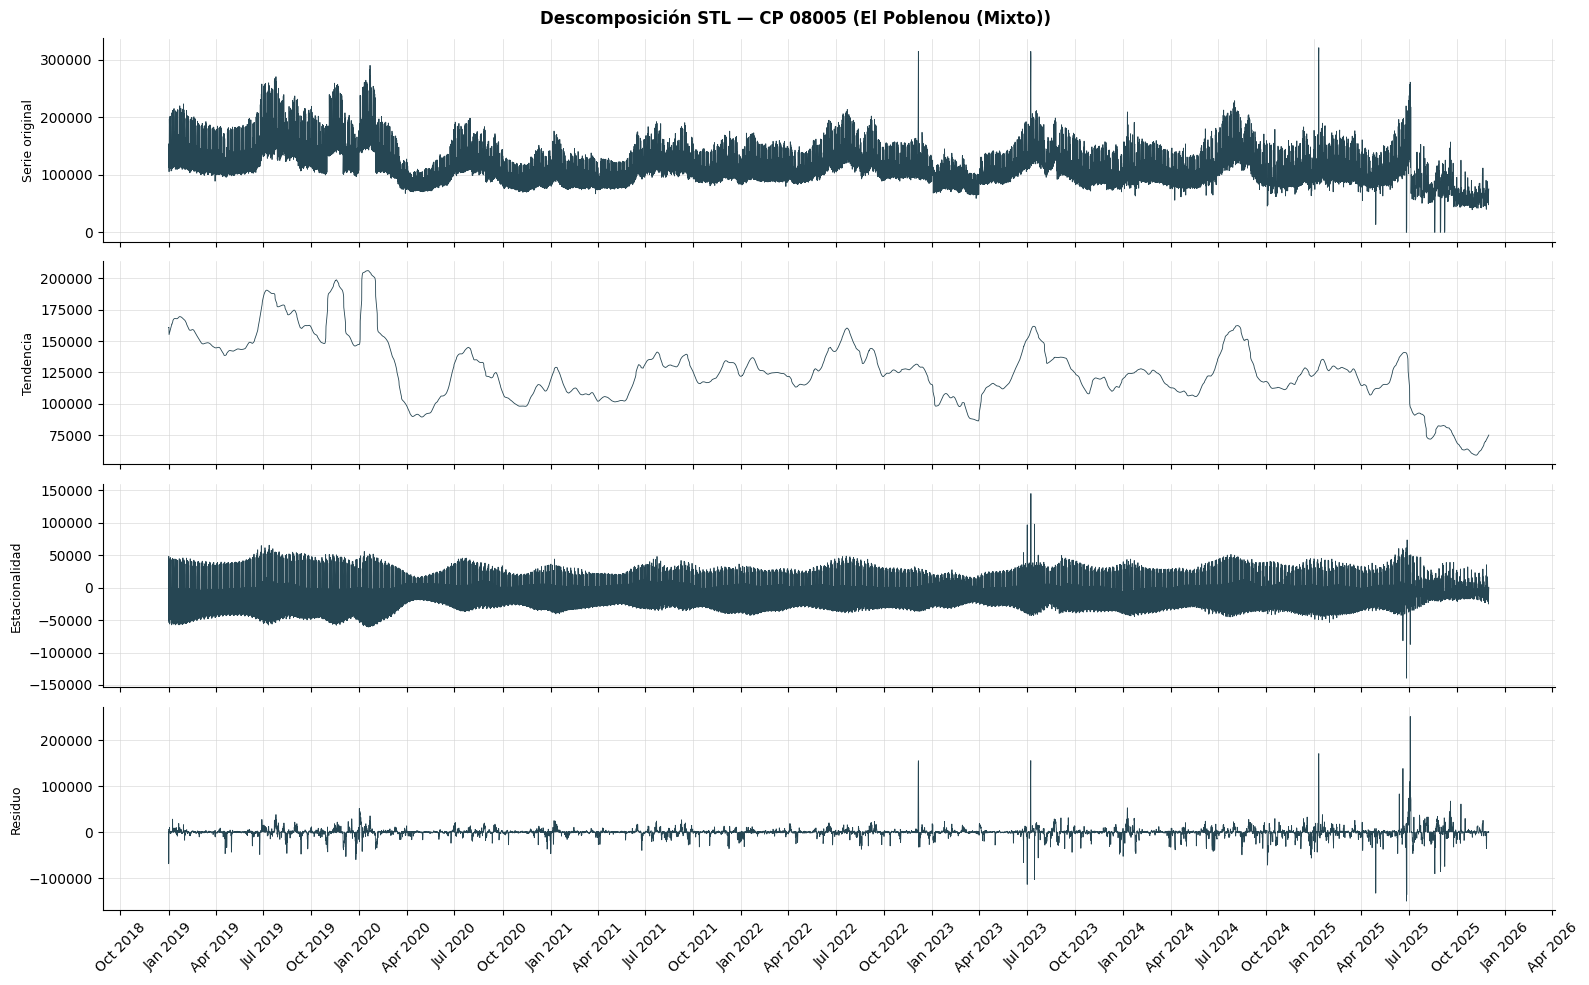

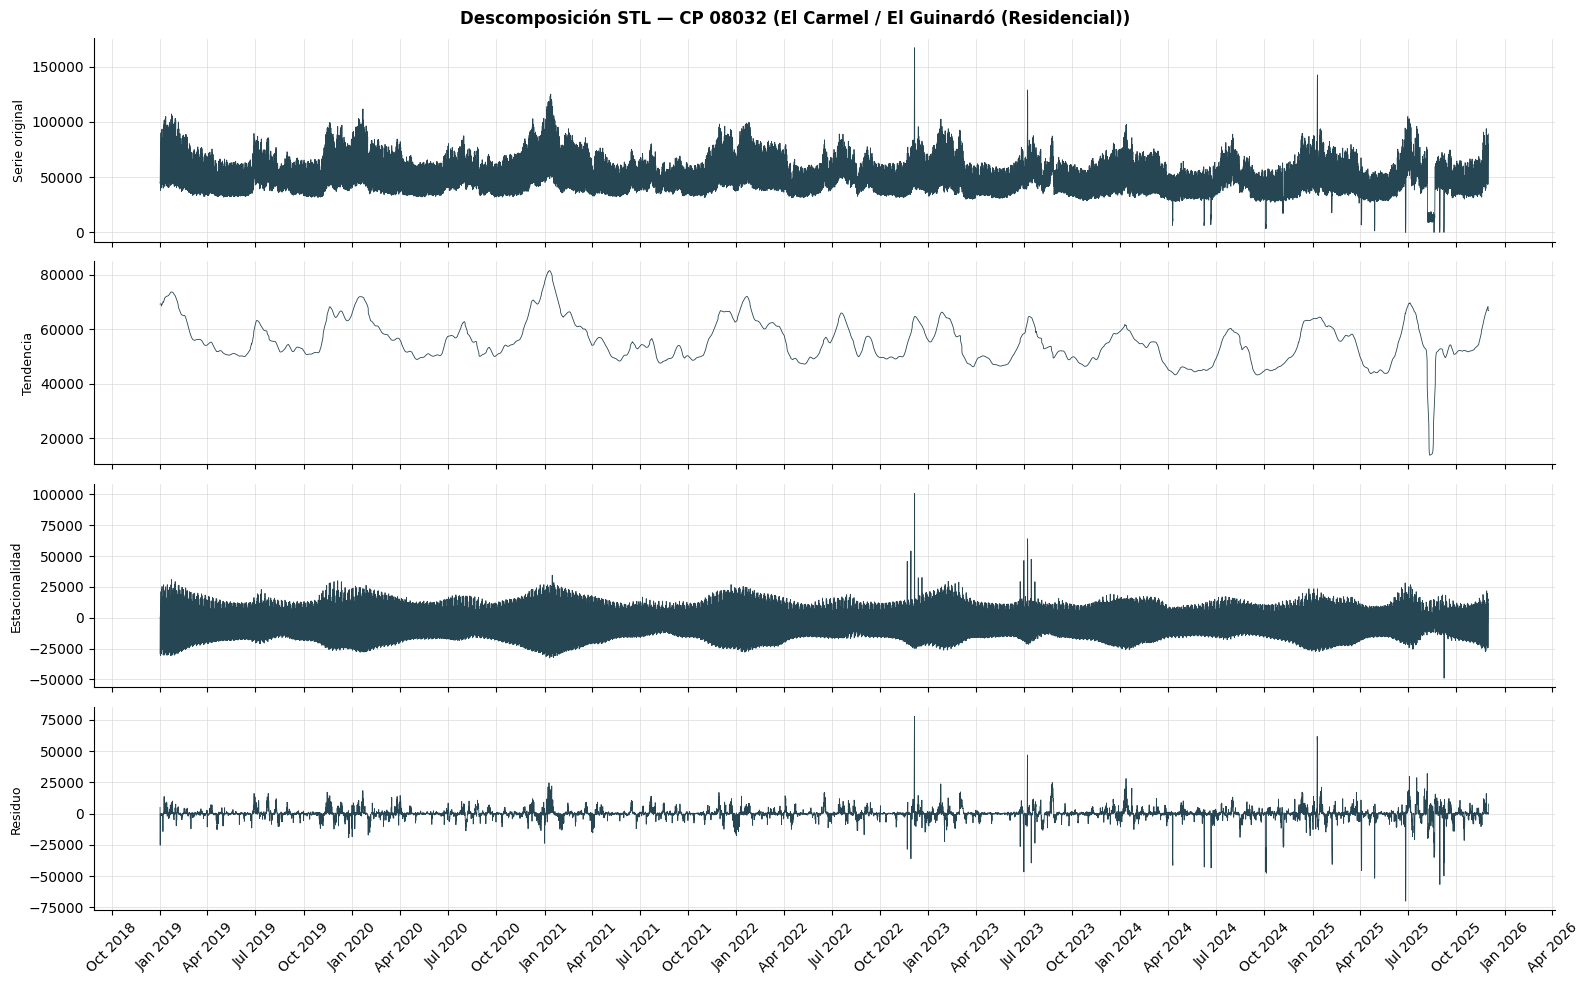

In [41]:
for cp, nombre in {k: v for k, v in CPS.items() if k != "08002"}.items():
    serie_cp = (
        df.filter(pl.col("cod_postal") == cp)
        .sort("datetime")
        .select(["datetime", "mwh_total"])
    )

    fechas     = serie_cp["datetime"].to_numpy()
    serie_vals = serie_cp["mwh_total"].to_numpy()

    res = STL(serie_vals, period=28, robust=True).fit()

    fig, axes = plt.subplots(4, 1, figsize=(16, 10), sharex=True)
    fig.suptitle(f"Descomposición STL — CP {cp} ({nombre})", fontweight="bold")

    for ax, (nombre_comp, vals) in zip(axes, {
        "Serie original": serie_vals,
        "Tendencia":      res.trend,
        "Estacionalidad": res.seasonal,
        "Residuo":        res.resid,
    }.items()):
        ax.plot(fechas, vals, color="#264653", linewidth=0.6)
        ax.set_ylabel(nombre_comp, fontsize=9)
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

>08038 Zona Franca (Industrial):

- Tendencia: inestable con caída pronunciada en COVID 2020 (~100k MWh) y picos en 2023-2024 (230k MWh)
- Estacionalidad: semanal pronunciada (±50k MWh), con amplitud que colapsa durante COVID y se recupera progresivamente. El ciclo anual queda absorbido en la tendencia como ondulaciones de verano.
- Residuo: cercano a 0 la mayor parte del tiempo, con picos en 2022-2024.

08005 El Poblenou (Mixto):
- Tendencia: caída COVID moderada (80k MWh) con recuperación lenta, el distrito tardó en retomar actividad. Oscilaciones anuales visibles pero menos pronunciadas que en perfiles industriales o turísticos.
- Estacionalidad: semanal estable y consistente ( oscila aproximadamente 40k MWh) a lo largo de toda la serie, sin grandes variaciones de amplitud entre años.
- Residuo: el más limpio de los 4 CPs, con picos puntuales en 2022-2023 Confirma que El Poblenou es el CP más predecible del conjunto.

>08032 El Carmel (Residencial):
- Tendencia: oscilaciones anuales más marcadas que los otros CPs, picos de invierno y valles de primavera claramente visibles. Impacto COVID el más suave de los 4, coherente con un perfil que no depende de actividad económica externa.
- Estacionalidad: semanal de menor amplitud (menor oscilación de apróximadamente 20k MWh) y más estable que los perfiles industriales o turísticos , el consumo residencial varía menos entre días laborables y fin de semana como vimos anteriormente
- Residuo: muy cercano a 0 con picos mínimos. La serie residencial es la más regular y estable del conjunto, lo que anticipa menores errores de predicción.

#### Análisis Vibriante

#### Análisis Correlación

### ADF Y KPSS

- ADF: Augmented Dickey-Fuller. Detecta si la serie tiene raíz unitaria (tendencia que no vuelve a un valor fijo). H0: la serie NO es estacionaria.

- KPSS: Kwiatkowski-Phillips-Schmidt-Shin. Lo contrario: H0: la serie SÍ es estacionaria.

Se usan juntos porque se contradicen, si ambos coinciden la conclusión es clara, si no coinciden hay estacionariedad parcial.

In [42]:
from statsmodels.tsa.stattools import adfuller, kpss

resultados = []

for cp, nombre in CPS.items():
    serie = (
        df.filter(pl.col("cod_postal") == cp)
        .sort("datetime")["mwh_total"]
        .to_numpy()
    )

    adf_stat, adf_p, _, _, _, _ = adfuller(serie, autolag="AIC")
    kpss_stat, kpss_p, _, _ = kpss(serie, regression="c", nlags="auto")

    resultados.append({
        "CP": cp,
        "Barrio": nombre,
        "ADF stat": round(adf_stat, 3),
        "ADF p-valor": round(adf_p, 4),
        "ADF estacionaria": "✅ Sí" if adf_p < 0.05 else "❌ No",
        "KPSS stat": round(kpss_stat, 3),
        "KPSS p-valor": round(kpss_p, 4),
        "KPSS estacionaria": "✅ Sí" if kpss_p > 0.05 else "❌ No",
    })

import pandas as pd
pd.DataFrame(resultados)

TypeError: deprecate_kwarg() missing 1 required positional argument: 'new_arg_name'

## <font color='#4E8F6E'>  **Variables Explicativas Numéricas** </font>


#### <font color='#D4B93A'><b>Revisión</b></font>


In [ ]:
VARS_NUM = ['mwh_industria', 'mwh_residencial', 'mwh_servicios', 'mwh_no_especificado',
            'lst_celsius', 'temp_mean', 'temp_max', 'temp_min',
            'humedad_mean', 'viento_mean', 'precipitacion_sum', 'irradiancia_mean']

df_num = df.select(VARS_NUM)
df_num.head(6)


mwh_industria,mwh_residencial,mwh_servicios,mwh_no_especificado,lst_celsius,temp_mean,temp_max,temp_min,humedad_mean,viento_mean,precipitacion_sum,irradiancia_mean
f64,f64,f64,i64,f64,f64,f64,f64,f64,f64,f64,f64
727.0,28259.0,39695.0,null,12.57,9.883333,11.1,8.8,59.166667,0.466667,0.0,0.0
736.0,25879.0,37506.0,null,12.43,10.25,11.0,9.2,52.75,1.158333,0.0,0.0
771.0,27820.0,39392.0,null,11.49,8.85,9.4,8.0,53.083333,1.041667,0.0,0.0
816.0,29064.0,39551.0,null,11.79,7.333333,8.0,6.7,61.416667,0.358333,0.0,0.0
723.0,31262.0,41953.0,null,10.38,8.25,8.8,7.5,66.416667,2.666667,0.0,0.0
729.0,30869.0,41162.0,null,13.57,11.008333,11.5,10.4,38.916667,1.191667,0.0,0.0


In [ ]:
df.select(VARS_NUM + ['mwh_total']).null_count()

mwh_industria,mwh_residencial,mwh_servicios,mwh_no_especificado,lst_celsius,temp_mean,temp_max,temp_min,humedad_mean,viento_mean,precipitacion_sum,irradiancia_mean,mwh_total
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
2664,260,220,362224,169044,28132,136747,136747,28121,153421,136648,153416,2664


#### <font color='#D4B93A'><b>Resumen Descriptivo de variables numéricas</b></font>


In [ ]:
df.select(VARS_NUM).describe()

statistic,mwh_industria,mwh_residencial,mwh_servicios,mwh_no_especificado,lst_celsius,temp_mean,temp_max,temp_min,humedad_mean,viento_mean,precipitacion_sum,irradiancia_mean
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",421704.0,424108.0,424148.0,62144.0,255324.0,396236.0,287621.0,287621.0,396247.0,270947.0,287720.0,270952.0
"""null_count""",2664.0,260.0,220.0,362224.0,169044.0,28132.0,136747.0,136747.0,28121.0,153421.0,136648.0,153416.0
"""mean""",8853.588758,35588.854379,56874.250571,521.674836,24.770183,17.873606,19.235217,16.509833,67.649343,2.540296,0.331734,186.820934
"""std""",19384.322529,19574.483828,39680.883725,3023.181272,9.119631,6.281664,6.321543,6.173686,15.410174,1.638099,2.333177,227.300742
"""min""",0.0,0.0,0.0,0.0,0.77,-0.258333,0.2,-5.7,4.0,0.0,0.0,-4.272727
"""25%""",776.0,21561.0,27197.0,75.0,16.69,12.972727,14.2,11.7,57.0,1.408333,0.0,0.0
"""50%""",1810.0,33159.0,47801.0,161.0,25.22,17.383333,18.8,15.9,68.0,2.166667,0.0,27.083333
"""75%""",4425.0,46510.0,76395.0,341.0,32.61,23.025,24.3,21.6,78.75,3.225,0.0,352.333333
"""max""",434408.0,260278.0,466750.0,115481.0,45.76,36.0,38.4,34.6,100.0,17.275,66.3,917.6


In [ ]:
# Top 10 registros por consumo — revisar si las variables coinciden en extremos
df.sort('mwh_total', descending=True).select(
    ['datetime', 'cod_postal', 'mwh_total', 'temp_mean', 'lst_celsius', 'hora', 'mes']
).head(10)


datetime,cod_postal,mwh_total,temp_mean,lst_celsius,hora,mes
datetime[μs],str,f64,f64,f64,i8,i8
2024-06-08 00:00:00,"""08001""",null,24.091667,null,0,6
2024-10-03 00:00:00,"""08001""",null,15.166667,null,0,10
2025-04-03 00:00:00,"""08001""",null,13.35,null,0,4
2025-08-19 00:00:00,"""08001""",null,null,null,0,8
2024-06-08 06:00:00,"""08001""",null,25.141667,null,6,6
2024-10-03 06:00:00,"""08001""",null,18.408333,null,6,10
2025-04-03 06:00:00,"""08001""",null,15.125,null,6,4
2025-08-19 06:00:00,"""08001""",null,null,null,6,8
2024-06-08 12:00:00,"""08001""",null,23.508333,null,12,6


> *(Anotar coincidencias entre picos de consumo y temperatura extrema, hora punta, mes de verano/invierno)*


NameError: name 'VERDE' is not defined

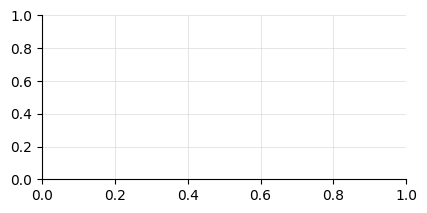

In [ ]:
# Histogramas + boxplots para todas las variables numéricas
n_cols = 3
n_rows = int(np.ceil(len(VARS_NUM) / n_cols))

fig = plt.figure(figsize=(16, n_rows * 5))

for i, var in enumerate(VARS_NUM):
    v = df[var].drop_nulls().to_numpy()
    
    # Histograma
    ax1 = fig.add_subplot(n_rows * 2, n_cols, (i // n_cols) * n_cols * 2 + (i % n_cols) + 1)
    ax1.hist(v, bins=30, color=VERDE, edgecolor='white', alpha=0.85)
    ax1.set_title(var, fontsize=9)
    ax1.set_ylabel('Frecuencia', fontsize=7)
    
    # Boxplot
    ax2 = fig.add_subplot(n_rows * 2, n_cols, (i // n_cols) * n_cols * 2 + n_cols + (i % n_cols) + 1)
    ax2.boxplot(v, vert=False, patch_artist=True,
                boxprops=dict(facecolor=VERDE, alpha=0.7),
                medianprops=dict(color='#2d5a42', linewidth=1.5),
                flierprops=dict(marker='o', markersize=1.5, alpha=0.3))
    ax2.set_xlabel('', fontsize=7)

plt.suptitle('Distribución de variables numéricas', fontsize=13, y=1.01, fontweight='bold')
plt.tight_layout()
plt.show()
